# Validation Trace And Answer Analysis

In [1]:
%matplotlib inline
from IPython.display import display
from collections import Counter
import json
import math
from pathlib import Path
import re
import statistics

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

ROOT_CANDIDATES = [Path.cwd(), Path.cwd().parent, Path("/home/csalt/Haider/DVLM/lvar")]
ROOT = next((p.resolve() for p in ROOT_CANDIDATES if (p / "outputs/inference/validation_oracle").exists()), None)
if ROOT is None:
    raise FileNotFoundError("Could not locate repo root containing outputs/inference/validation_oracle")

INFERENCE_ROOT = ROOT / "outputs/inference/validation_oracle"
FULL_LVAR_ROOT = ROOT / "outputs/inference/current_lvar_model_validation"
TRACE_ROOT = ROOT / "outputs/oracle_dataset/validation"
M3COT_OUTPUT_DIR = Path(
    "/home/csalt/Haider/DVLM/IVT-LR/qwen_vl/outputs_lvar/inference/m3cot"
)
LOG_NAME = "qwen_m3cot_infer_stdout_stderr.log"
FINAL_RESULT_RE = re.compile(
    r"\[FINAL\]\s+Total:\s*(?P<total>\d+),\s*"
    r"Correct:\s*(?P<correct>\d+),\s*"
    r"Accuracy:\s*(?P<accuracy>[0-9]+(?:\.[0-9]+)?)%"
)


def setting_sort_key(setting):
    match = re.fullmatch(r"latent_steps_(\d+)", setting)
    if match:
        return (0, int(match.group(1)))
    if setting == "dynamic_latent_steps":
        return (1, 0)
    return (2, setting)


if not M3COT_OUTPUT_DIR.is_dir():
    raise FileNotFoundError(f"M3CoT output directory not found: {M3COT_OUTPUT_DIR}")

print(f"ROOT: {ROOT}")
print(f"INFERENCE_ROOT exists: {INFERENCE_ROOT.exists()} -> {INFERENCE_ROOT}")
print(f"FULL_LVAR_ROOT exists: {FULL_LVAR_ROOT.exists()} -> {FULL_LVAR_ROOT}")
print(f"TRACE_ROOT exists: {TRACE_ROOT.exists()} -> {TRACE_ROOT}")

ROOT: /home/csalt/Haider/DVLM/lvar
INFERENCE_ROOT exists: True -> /home/csalt/Haider/DVLM/lvar/outputs/inference/validation_oracle
FULL_LVAR_ROOT exists: True -> /home/csalt/Haider/DVLM/lvar/outputs/inference/current_lvar_model_validation
TRACE_ROOT exists: True -> /home/csalt/Haider/DVLM/lvar/outputs/oracle_dataset/validation


## Helpers

The helpers below normalize naming across paths, load JSONL safely, and derive trace-level metrics from both high-level decisions and primitive trace actions.

In [2]:
rows = []
for log_path in M3COT_OUTPUT_DIR.glob(f"*/{LOG_NAME}"):
    matches = list(FINAL_RESULT_RE.finditer(log_path.read_text(errors="replace")))
    if not matches:
        print(f"Warning: no [FINAL] result found in {log_path}")
        continue

    result = matches[-1].groupdict()
    rows.append(
        {
            "setting": log_path.parent.name,
            "total": int(result["total"]),
            "correct": int(result["correct"]),
            "accuracy_pct": float(result["accuracy"]),
        }
    )

if not rows:
    raise RuntimeError(f"No final accuracy results found under {M3COT_OUTPUT_DIR}")

m3cot_accuracy = (
    pd.DataFrame(rows)
    .sort_values("setting", key=lambda column: column.map(setting_sort_key))
    .reset_index(drop=True)
)
display(
    m3cot_accuracy.style
    .format({"accuracy_pct": "{:.2f}%"})
    .hide(axis="index")
)

setting,total,correct,accuracy_pct
latent_steps_0,1108,649,58.57%
latent_steps_1,1108,671,60.56%
latent_steps_2,1108,679,61.28%
latent_steps_3,1108,675,60.92%
latent_steps_4,1108,672,60.65%
latent_steps_5,1108,668,60.29%
latent_steps_6,1108,673,60.74%
latent_steps_7,1108,663,59.84%
latent_steps_8,1108,651,58.75%
dynamic_latent_steps,1108,668,60.29%


In [3]:
def load_json(path):
    path = Path(path)
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def load_jsonl(path):
    path = Path(path)
    rows = []
    bad_rows = []
    with path.open("r", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            stripped = line.strip()
            if not stripped:
                continue
            try:
                rows.append(json.loads(stripped))
            except json.JSONDecodeError as exc:
                bad_rows.append({
                    "path": str(path),
                    "line_number": line_number,
                    "error": str(exc),
                    "context": stripped[max(0, exc.pos - 100): exc.pos + 100],
                })
    return rows, bad_rows


ANSWER_PATTERNS = [
    re.compile(r"(?:answer|option|choice)\s*(?:is|:|=)?\s*[\(\[]?([A-D])\b", re.IGNORECASE),
    re.compile(r"\b([A-D])\s*(?:is|would be)\s*(?:the\s*)?(?:correct\s*)?(?:answer|option|choice)\b", re.IGNORECASE),
]


def normalize_answer(value):
    if value is None:
        return None
    match = re.search(r"\b([A-D])\b", str(value).upper())
    return match.group(1) if match else None


def decoded_response_from_messages(messages):
    if not isinstance(messages, list) or not messages:
        return ""
    return str(messages[-1])


def extract_answer_from_response(response):
    response = str(response or "")
    matches = []
    for pattern in ANSWER_PATTERNS:
        matches.extend(match.group(1).upper() for match in pattern.finditer(response))
    if matches:
        return matches[-1]

    standalone = re.findall(r"(?<![A-Z])([A-D])(?![A-Z])", response.upper())
    return standalone[-1] if standalone else None


def clean_ckpt_name(value):
    if value is None:
        return None
    value = str(value)
    value = value.replace("mined_by_", "").replace("evaluated_by_", "")
    value = value.replace("_ckpt", "")
    return value


def pretty_variant(value):
    mapping = {
        "raw": "raw",
        "filtered_cap": "filtered (cap)",
        "filtered_no_cap": "filtered (no cap)",
    }
    return mapping.get(str(value), str(value))


def parse_inference_summary_path(path):
    parts = Path(path).parts
    mined_by = next((clean_ckpt_name(p) for p in parts if p.startswith("mined_by_")), None)
    evaluated_by = next((clean_ckpt_name(p) for p in parts if p.startswith("evaluated_by_")), None)
    variant_dir = next((p.replace("trace_variant_", "") for p in parts if p.startswith("trace_variant_")), None)
    return mined_by, evaluated_by, variant_dir


def parse_trace_path(path):
    path = Path(path)
    match = re.search(r"m3cot_validation_traces_(?P<mined_by>.+?)_(?P<context>global|coarse)\.jsonl$", path.name)
    mined_by = match.group("mined_by") if match else clean_ckpt_name(path.parent.name)
    context = match.group("context") if match else None
    return clean_ckpt_name(mined_by), context


def parse_mining_and_replay_context(summary, artifact_path):
    trace_path = summary.get("trace_path")
    mining_context = parse_trace_path(trace_path)[1] if trace_path else None
    suffix = re.search(r"_replayed-under_(global|coarse|full_context|global_mean)(?:_|\.)", Path(artifact_path).name)
    replay_context = suffix.group(1) if suffix else mining_context
    return mining_context, replay_context


def action_type(action):
    return str(action.get("type", action.get("action", "UNKNOWN"))).upper()


def action_index(action):
    if "patch_idx" in action:
        return action.get("patch_idx")
    if "patch_index" in action:
        return action.get("patch_index")
    if "region_idx" in action:
        return action.get("region_idx")
    if "region_index" in action:
        return action.get("region_index")
    return None


def decision_reduction(decision):
    if decision.get("improvement") is not None:
        return float(decision.get("improvement"))
    ce_noop = decision.get("ce_noop")
    ce_selected = decision.get("ce_selected")
    if ce_noop is not None and ce_selected is not None:
        return float(ce_noop) - float(ce_selected)
    return np.nan


def finite_mean(values):
    values = [float(v) for v in values if pd.notna(v)]
    return float(np.mean(values)) if values else np.nan


def finite_sum(values):
    values = [float(v) for v in values if pd.notna(v)]
    return float(np.sum(values)) if values else np.nan


def infer_grid_size(indices):
    indices = [int(i) for i in indices if pd.notna(i)]
    if not indices:
        return 1
    return int(math.ceil(math.sqrt(max(indices) + 1)))

def setting_sort_key(setting):
    match = re.fullmatch(r"latent_steps_(\d+)", setting)
    if match:
        return (0, int(match.group(1)))
    if setting == "dynamic_latent_steps":
        return (1, 0)
    return (2, setting)

## M3CoT Latent-Step Oracle From Decoded Responses

This reloads `qwen_m3cot_predictions.jsonl` from `latent_steps_0` through `latent_steps_8`, ignores `dynamic_latent_steps`, extracts the answer from the decoded response in `messages[-1]`, and marks each question correct if any fixed latent-step variant answered correctly.

In [4]:
M3COT_PREDICTIONS_NAME = "qwen_m3cot_predictions.jsonl"
EXPECTED_LATENT_STEPS = list(range(9))

m3cot_prediction_rows = []
m3cot_bad_prediction_rows = []

for prediction_path in sorted(M3COT_OUTPUT_DIR.glob(f"latent_steps_*/{M3COT_PREDICTIONS_NAME}")):
    setting = prediction_path.parent.name
    match = re.fullmatch(r"latent_steps_(\d+)", setting)
    if not match:
        continue

    latent_steps = int(match.group(1))
    if latent_steps not in EXPECTED_LATENT_STEPS:
        continue

    rows, bad_rows = load_jsonl(prediction_path)
    m3cot_bad_prediction_rows.extend(bad_rows)
    for row in rows:
        decoded_response = decoded_response_from_messages(row.get("messages"))
        gold_answer = normalize_answer(row.get("answer"))
        decoded_answer = extract_answer_from_response(decoded_response)
        m3cot_prediction_rows.append({
            "example_id": row.get("id") or row.get("example_id"),
            "latent_steps": latent_steps,
            "setting": setting,
            "domain": row.get("domain"),
            "topic": row.get("topic"),
            "gold_answer": gold_answer,
            "decoded_answer": decoded_answer,
            "correct": decoded_answer == gold_answer if gold_answer and decoded_answer else False,
            "question": row.get("messages", [None])[0] if row.get("messages") else None,
            "decoded_response": decoded_response,
            "prediction_path": str(prediction_path),
        })

m3cot_predictions = pd.DataFrame(m3cot_prediction_rows)
if m3cot_predictions.empty:
    raise RuntimeError(f"No fixed-step M3CoT prediction rows found under {M3COT_OUTPUT_DIR}")

missing_latent_steps = sorted(set(EXPECTED_LATENT_STEPS) - set(m3cot_predictions["latent_steps"].unique()))
if missing_latent_steps:
    print(f"Warning: missing fixed latent-step prediction files for steps: {missing_latent_steps}")
if m3cot_bad_prediction_rows:
    print(f"Warning: {len(m3cot_bad_prediction_rows):,} malformed JSONL rows while loading M3CoT predictions")

m3cot_latent_accuracy = (
    m3cot_predictions
    .groupby(["latent_steps", "setting"], as_index=False)
    .agg(total=("example_id", "nunique"), correct=("correct", "sum"))
    .sort_values("latent_steps")
)
m3cot_latent_accuracy["accuracy_pct"] = 100 * m3cot_latent_accuracy["correct"] / m3cot_latent_accuracy["total"]
display(m3cot_latent_accuracy.style.format({"accuracy_pct": "{:.2f}%"}).hide(axis="index"))


latent_steps,setting,total,correct,accuracy_pct
0,latent_steps_0,1108,648,58.48%
1,latent_steps_1,1108,664,59.93%
2,latent_steps_2,1108,672,60.65%
3,latent_steps_3,1108,670,60.47%
4,latent_steps_4,1108,667,60.20%
5,latent_steps_5,1108,662,59.75%
6,latent_steps_6,1108,668,60.29%
7,latent_steps_7,1108,658,59.39%
8,latent_steps_8,1108,646,58.30%


In [ ]:
oracle_rows = []
for example_id, group in m3cot_predictions.groupby("example_id", dropna=False):
    group = group.sort_values("latent_steps")
    correct_steps = group.loc[group["correct"], "latent_steps"].astype(int).tolist()
    first = group.iloc[0]
    oracle_rows.append({
        "example_id": example_id,
        "domain": first.get("domain"),
        "topic": first.get("topic"),
        "gold_answer": first.get("gold_answer"),
        "oracle_correct": bool(correct_steps),
        "num_correct_latent_steps": len(correct_steps),
        "correct_latent_steps": correct_steps,
        "ideal_latent_steps": correct_steps[0] if correct_steps else np.nan,
        "question": first.get("question"),
    })

m3cot_oracle_by_question = pd.DataFrame(oracle_rows).sort_values(["oracle_correct", "num_correct_latent_steps", "example_id"], ascending=[False, False, True])

correct_wide = (
    m3cot_predictions
    .pivot_table(index="example_id", columns="latent_steps", values="correct", aggfunc="first")
    .rename(columns=lambda step: f"correct_at_step_{step}")
    .reset_index()
)
answer_wide = (
    m3cot_predictions
    .pivot_table(index="example_id", columns="latent_steps", values="decoded_answer", aggfunc="first")
    .rename(columns=lambda step: f"answer_at_step_{step}")
    .reset_index()
)
m3cot_oracle_by_question = m3cot_oracle_by_question.merge(correct_wide, on="example_id", how="left").merge(answer_wide, on="example_id", how="left")

m3cot_oracle_summary = pd.DataFrame([{
    "questions": m3cot_oracle_by_question["example_id"].nunique(),
    "oracle_correct": int(m3cot_oracle_by_question["oracle_correct"].sum()),
    "oracle_accuracy_pct": 100 * m3cot_oracle_by_question["oracle_correct"].mean(),
    "avg_correct_latent_steps_per_question": m3cot_oracle_by_question["num_correct_latent_steps"].mean(),
}])

display(m3cot_oracle_summary.style.format({
    "oracle_accuracy_pct": "{:.2f}%",
    "avg_correct_latent_steps_per_question": "{:.2f}",
}).hide(axis="index"))

# display(m3cot_oracle_by_question.style.format({"ideal_latent_steps": "{:.0f}"}, na_rep="-").hide(axis="index"))
m3cot_oracle_by_question.head()

questions,oracle_correct,oracle_accuracy_pct,avg_correct_latent_steps_per_question
1108,755,68.14%,5.37


,example_id,domain,topic,gold_answer,oracle_correct,num_correct_latent_steps,correct_latent_steps,ideal_latent_steps,question,correct_at_step_0,correct_at_step_1,correct_at_step_2,correct_at_step_3,correct_at_step_4,correct_at_step_5,correct_at_step_6,correct_at_step_7,correct_at_step_8,answer_at_step_0,answer_at_step_1,answer_at_step_2,answer_at_step_3,answer_at_step_4,answer_at_step_5,answer_at_step_6,answer_at_step_7,answer_at_step_8
0,biology-1001,science,natural-science,A,True,9,"[0, 1, 2, 3, 4, 5, 6, 7, 8]",0.0,"[Question]:{From the visual representation, identify the scientific name of the organism.}\n[Options]:\nA.{Lithobates catesbeianus}\nB.{...",True,True,True,True,True,True,True,True,True,A,A,A,A,A,A,A,A,A
1,biology-1024,science,natural-science,A,True,9,"[0, 1, 2, 3, 4, 5, 6, 7, 8]",0.0,[Question]:{Select the true statement.}\n[Options]:\nA.{Genes affect traits.}\nB.{Eye color is an example of a gene.},True,True,True,True,True,True,True,True,True,A,A,A,A,A,A,A,A,A
2,biology-1038,science,natural-science,A,True,9,"[0, 1, 2, 3, 4, 5, 6, 7, 8]",0.0,"[Question]:{Based on this information, what is this plant's phenotype for the flower form trait?}\n[Options]:\nA.{single flowers}\nB.{do...",True,True,True,True,True,True,True,True,True,A,A,A,A,A,A,A,A,A
3,biology-1067,science,natural-science,A,True,9,"[0, 1, 2, 3, 4, 5, 6, 7, 8]",0.0,"[Question]:{Using the provided image, figure out the scientific name of the organism it portrays.}\n[Options]:\nA.{Alouatta palliata}\nB...",True,True,True,True,True,True,True,True,True,A,A,A,A,A,A,A,A,A
4,biology-1086,science,natural-science,A,True,9,"[0, 1, 2, 3, 4, 5, 6, 7, 8]",0.0,"[Question]:{Based on this information, what is Fawkes's phenotype for the cheek color trait?}\n[Options]:\nA.{pale orange cheeks}\nB.{br...",True,True,True,True,True,True,True,True,True,A,A,A,A,A,A,A,A,A


In [56]:
m3cot_oracle_by_question.loc[(m3cot_oracle_by_question["correct_at_step_0"] == True) & (m3cot_oracle_by_question["correct_at_step_1"] == False) & (m3cot_oracle_by_question["correct_at_step_2"] == False) & (m3cot_oracle_by_question["correct_at_step_3"] == False) & (m3cot_oracle_by_question["correct_at_step_4"] == False) & (m3cot_oracle_by_question["correct_at_step_5"] == False) & (m3cot_oracle_by_question["correct_at_step_6"] == False) & (m3cot_oracle_by_question["correct_at_step_7"] == False) & (m3cot_oracle_by_question["correct_at_step_8"] == False)].shape

(29, 27)

## 1. Final Accuracy Across Inference Settings

This scans all `*_summary.json` files in the oracle inference directory and adds the full LVAR model + controller run from `outputs/inference/current_lvar_model`. Placeholder metadata (`mined_by=full_lvar`, `evaluated_by=lvar+controller`, `trace_variant=controller-generated`) keeps both run types in one table.


In [6]:
summary_rows = []
for path in sorted(INFERENCE_ROOT.rglob("*_summary.json")):
    summary = load_json(path)
    mined_by, evaluated_by, variant_from_path = parse_inference_summary_path(path)
    metrics = summary.get("metrics", {}) or {}
    trace_variant = summary.get("trace_variant") or variant_from_path
    mining_context, replay_context = parse_mining_and_replay_context(summary, path)
    summary_rows.append({
        "run_type": "oracle",
        "mined_by": mined_by,
        "context": mining_context,
        "replay_context": replay_context,
        "evaluated_by": evaluated_by,
        "trace_variant": trace_variant,
        "trace_variant_label": pretty_variant(trace_variant),
        "accuracy": metrics.get("accuracy"),
        "correct": metrics.get("correct"),
        "total": metrics.get("total"),
        "avg_trace_actions": metrics.get("avg_trace_actions"),
        "avg_output_tokens": metrics.get("avg_output_tokens"),
        "kept_primitives": (summary.get("transform_totals") or {}).get("kept_primitives"),
        "summary_path": str(path.relative_to(ROOT)),
    })

full_lvar_summary_path = FULL_LVAR_ROOT / "m3cot_lvar_predictions_summary.json"
if full_lvar_summary_path.exists():
    summary = load_json(full_lvar_summary_path)
    metrics = summary.get("metrics", {}) or {}
    summary_rows.append({
        "run_type": "full_lvar",
        "mined_by": "full_lvar",
        "context": "coarse" if summary.get("coarse_context") else "global",
        "replay_context": "coarse" if summary.get("coarse_context") else "global",
        "evaluated_by": "lvar+controller",
        "trace_variant": "controller_generated",
        "trace_variant_label": "controller-generated",
        "accuracy": metrics.get("accuracy"),
        "correct": metrics.get("correct"),
        "total": metrics.get("total") or summary.get("num_examples"),
        "avg_trace_actions": metrics.get("avg_controller_actions"),
        "avg_output_tokens": metrics.get("avg_output_tokens"),
        "kept_primitives": np.nan,
        "summary_path": str(full_lvar_summary_path.relative_to(ROOT)),
    })
else:
    print(f"Full LVAR summary not found: {full_lvar_summary_path}")

accuracy_df = pd.DataFrame(summary_rows)
if accuracy_df.empty:
    raise ValueError(f"No inference summaries found under {INFERENCE_ROOT} or {FULL_LVAR_ROOT}")

accuracy_df = accuracy_df.sort_values(["run_type", "mined_by", "context", "replay_context", "evaluated_by", "trace_variant_label"]).reset_index(drop=True)
accuracy_df["accuracy"] = 100 * pd.to_numeric(accuracy_df["accuracy"], errors="coerce")
accuracy_df


,run_type,mined_by,context,replay_context,evaluated_by,trace_variant,trace_variant_label,accuracy,correct,total,avg_trace_actions,avg_output_tokens,kept_primitives,summary_path
0,full_lvar,full_lvar,global,global,lvar+controller,controller_generated,controller-generated,60.74,673,1108,7.94,6.65,NaN,outputs/inference/current_lvar_model_validation/m3cot_lvar_predictions_summary.json
1,oracle,lvar,coarse,coarse,ivtlr,filtered_cap,filtered (cap),45.22,501,1108,7.83,6.00,8675.0,outputs/inference/validation_oracle/mined_by_lvar_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_validation_predictions_m...
2,oracle,lvar,coarse,coarse,ivtlr,filtered_no_cap,filtered (no cap),46.21,512,1108,11.37,6.00,12598.0,outputs/inference/validation_oracle/mined_by_lvar_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_no_cap/m3cot_validation_prediction...
3,oracle,lvar,coarse,coarse,ivtlr,raw,raw,46.66,517,1108,12.10,6.00,13404.0,outputs/inference/validation_oracle/mined_by_lvar_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_raw/m3cot_validation_predictions_mined-by_l...
4,oracle,lvar,coarse,coarse,lvar,filtered_cap,filtered (cap),51.90,575,1108,7.83,6.55,8675.0,outputs/inference/validation_oracle/mined_by_lvar_ckpt/evaluated_by_lvar_ckpt/trace_variant_filtered_cap/m3cot_validation_predictions_mi...
5,oracle,lvar,coarse,coarse,lvar,filtered_no_cap,filtered (no cap),58.03,643,1108,11.37,6.13,12598.0,outputs/inference/validation_oracle/mined_by_lvar_ckpt/evaluated_by_lvar_ckpt/trace_variant_filtered_no_cap/m3cot_validation_predictions...
6,oracle,lvar,coarse,coarse,lvar,raw,raw,59.93,664,1108,12.10,6.00,13404.0,outputs/inference/validation_oracle/mined_by_lvar_ckpt/evaluated_by_lvar_ckpt/trace_variant_raw/m3cot_validation_predictions_mined-by_lv...
7,oracle,lvar,coarse,global,ivtlr,filtered_cap,filtered (cap),64.62,716,1108,7.83,6.06,8675.0,outputs/inference/validation_oracle/mined_by_lvar_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_validation_predictions_m...
8,oracle,lvar,coarse,global,ivtlr,filtered_no_cap,filtered (no cap),64.62,716,1108,11.37,6.07,12598.0,outputs/inference/validation_oracle/mined_by_lvar_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_no_cap/m3cot_validation_prediction...
9,oracle,lvar,coarse,global,ivtlr,raw,raw,64.71,717,1108,12.10,6.04,13404.0,outputs/inference/validation_oracle/mined_by_lvar_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_raw/m3cot_validation_predictions_mined-by_l...


In [7]:
accuracy_pivot = (
    accuracy_df
    .pivot_table(
        index=["mined_by", "context", "replay_context", "evaluated_by"],
        columns="trace_variant_label",
        values="accuracy",
        aggfunc="first",
    )
    .sort_index()
)
accuracy_pivot.style.format("{:.2f}").set_caption("Accuracy (%) by mined trace, mining context, replay context, evaluator, and trace variant")

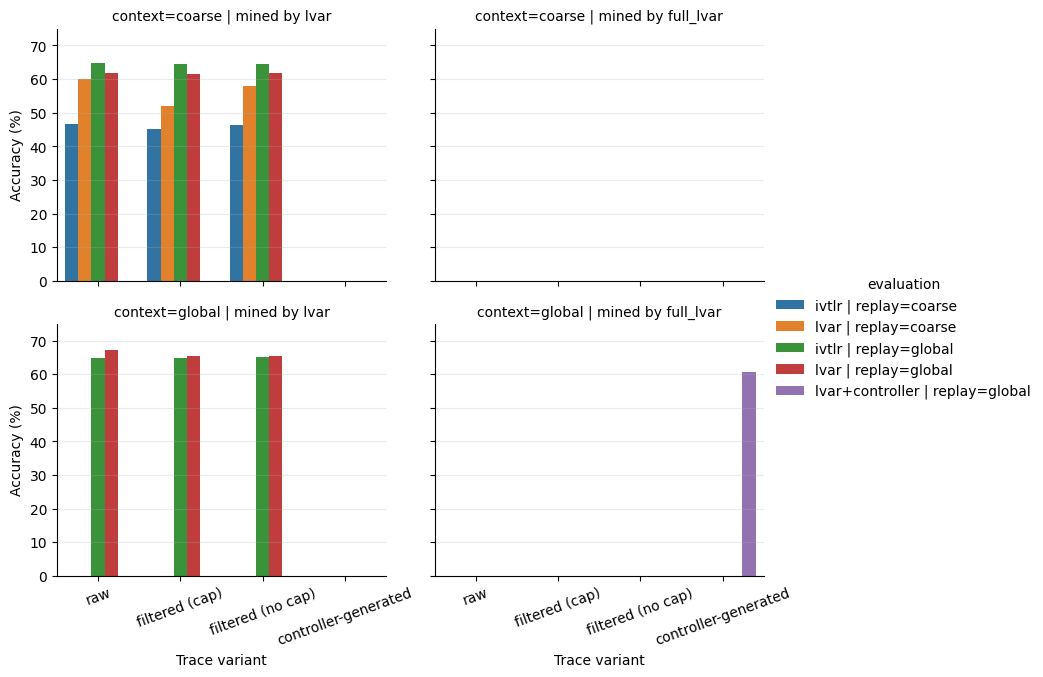

In [8]:
variant_order = ["raw", "filtered (cap)", "filtered (no cap)", "controller-generated"]
plot_df = accuracy_df.copy()
plot_df["run"] = (
    "mined=" + plot_df["mined_by"].astype(str)
    + " | eval=" + plot_df["evaluated_by"].astype(str)
    + " | mined context=" + plot_df["context"].astype(str)
    + " | replay=" + plot_df["replay_context"].astype(str)
)
plot_df["evaluation"] = plot_df["evaluated_by"].astype(str) + " | replay=" + plot_df["replay_context"].astype(str)
plot_df["trace_variant_label"] = pd.Categorical(plot_df["trace_variant_label"], categories=variant_order, ordered=True)
plot_df = plot_df.sort_values(["context", "replay_context", "mined_by", "evaluated_by", "trace_variant_label"])

if HAS_SEABORN:
    g = sns.catplot(
        data=plot_df,
        kind="bar",
        x="trace_variant_label",
        y="accuracy",
        hue="evaluation",
        col="mined_by",
        row="context",
        order=variant_order,
        height=3.2,
        aspect=1.25,
        sharey=True,
    )
    g.set_axis_labels("Trace variant", "Accuracy (%)")
    g.set_titles(row_template="context={row_name}", col_template="mined by {col_name}")
    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=20)
        ax.set_ylim(0, max(75, plot_df["accuracy"].max() + 5))
    plt.show()
else:
    available_variants = [v for v in variant_order if v in plot_df["trace_variant_label"].dropna().astype(str).unique()]
    ax = plot_df.pivot_table(index="run", columns="trace_variant_label", values="accuracy", aggfunc="first")[available_variants].plot(kind="bar", figsize=(13, 6))
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Accuracy by inference setting")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


In [9]:
best_by_setting = (
    accuracy_df
    .sort_values("accuracy", ascending=False)
    .loc[:, ["run_type", "mined_by", "context", "replay_context", "evaluated_by", "trace_variant_label", "accuracy", "correct", "total", "avg_trace_actions", "avg_output_tokens"]]
    .reset_index(drop=True)
)
best_by_setting.style.format({"accuracy": "{:.2f}", "avg_trace_actions": "{:.2f}", "avg_output_tokens": "{:.2f}"}).set_caption("Inference settings ranked by accuracy")


,run_type,mined_by,context,replay_context,evaluated_by,trace_variant_label,accuracy,correct,total,avg_trace_actions,avg_output_tokens
0,oracle,lvar,global,global,lvar,raw,67.15,744,1108,8.78,6.00
1,oracle,lvar,global,global,lvar,filtered (no cap),65.43,725,1108,7.70,6.49
2,oracle,lvar,global,global,lvar,filtered (cap),65.25,723,1108,6.44,6.62
3,oracle,lvar,global,global,ivtlr,filtered (no cap),65.16,722,1108,7.70,6.00
4,oracle,lvar,global,global,ivtlr,raw,64.89,719,1108,8.78,6.00
5,oracle,lvar,global,global,ivtlr,filtered (cap),64.71,717,1108,6.44,6.01
6,oracle,lvar,coarse,global,ivtlr,raw,64.71,717,1108,12.10,6.04
7,oracle,lvar,coarse,global,ivtlr,filtered (cap),64.62,716,1108,7.83,6.06
8,oracle,lvar,coarse,global,ivtlr,filtered (no cap),64.62,716,1108,11.37,6.07
9,oracle,lvar,coarse,global,lvar,filtered (no cap),61.91,686,1108,11.37,6.72


## 2. Load The Two Validation Traces

The four mined trace sets are expected to be `(lvar, global)`, `(lvar, coarse)`. 

In [10]:
trace_files = sorted(TRACE_ROOT.rglob("m3cot_validation_traces_*_*.jsonl"))
trace_manifest_rows = []
trace_records = []
bad_trace_rows = []

for path in trace_files:
    mined_by, context = parse_trace_path(path)
    summary_path = path.with_name(path.stem + "_summary.json")
    summary = load_json(summary_path) if summary_path.exists() else {}
    rows, bad_rows = load_jsonl(path)
    bad_trace_rows.extend(bad_rows)
    trace_manifest_rows.append({
        "mined_by": mined_by,
        "context": context,
        "num_rows_loaded": len(rows),
        "summary_exists": summary_path.exists(),
        "summary_num_examples": summary.get("num_examples"),
        "summary_num_decisions": summary.get("num_decisions"),
        "summary_mean_selected_improvement": summary.get("mean_selected_improvement"),
        "initial_visual_mode": summary.get("initial_visual_mode") or (rows[0].get("initial_visual_mode") if rows else None),
        "trace_path": str(path.relative_to(ROOT)),
        "summary_path": str(summary_path.relative_to(ROOT)) if summary_path.exists() else None,
    })
    for row in rows:
        rec = dict(row)
        rec["mined_by"] = mined_by
        rec["context"] = context
        rec["trace_file"] = str(path.relative_to(ROOT))
        trace_records.append(rec)

trace_manifest = pd.DataFrame(trace_manifest_rows).sort_values(["mined_by", "context"]).reset_index(drop=True)
print(f"Trace files loaded: {len(trace_files)}")
print(f"Trace rows loaded: {len(trace_records):,}")
print(f"Bad JSONL rows: {len(bad_trace_rows):,}")
trace_manifest

Trace files loaded: 2
Trace rows loaded: 2,216
Bad JSONL rows: 0


,mined_by,context,num_rows_loaded,summary_exists,summary_num_examples,summary_num_decisions,summary_mean_selected_improvement,initial_visual_mode,trace_path,summary_path
0,lvar,coarse,1108,True,1108,7223,0.114773,global_mean,outputs/oracle_dataset/validation/lvar_ckpt/m3cot_validation_traces_lvar_coarse.jsonl,outputs/oracle_dataset/validation/lvar_ckpt/m3cot_validation_traces_lvar_coarse_summary.json
1,lvar,global,1108,True,1108,7223,0.073775,full_context,outputs/oracle_dataset/validation/lvar_ckpt/m3cot_validation_traces_lvar_global.jsonl,outputs/oracle_dataset/validation/lvar_ckpt/m3cot_validation_traces_lvar_global_summary.json


In [11]:
expected_trace_keys = pd.MultiIndex.from_product([['ivtlr', 'lvar'], ['coarse', 'global']], names=['mined_by', 'context'])
actual_trace_keys = pd.MultiIndex.from_frame(trace_manifest[['mined_by', 'context']])
missing_trace_keys = expected_trace_keys.difference(actual_trace_keys)
print("Expected four trace sets present?", len(missing_trace_keys) == 0)
if len(missing_trace_keys):
    print("Missing:")
    display(missing_trace_keys.to_frame(index=False))

Expected four trace sets present? False
Missing:


,mined_by,context
0,ivtlr,coarse
1,ivtlr,global


## Flatten Trace Metrics

`trace_examples` is one row per example per mined trace set. `trace_actions` is one row per primitive action. `trace_decisions` is one row per mined decision step. These are the core tables used below.

In [12]:
example_rows = []
action_rows = []
decision_rows = []
counterfactual_rows = []

for row in trace_records:
    mined_by = row["mined_by"]
    context = row["context"]
    example_id = row.get("example_id")
    decisions = row.get("decisions") or []
    trace = row.get("trace") or []
    steps = row.get("steps") or []
    question = row.get("question")

    reductions = [decision_reduction(d) for d in decisions]
    ce_noop_values = [d.get("ce_noop") for d in decisions if d.get("ce_noop") is not None]
    ce_selected_values = [d.get("ce_selected") for d in decisions if d.get("ce_selected") is not None]
    selected_names = [str(d.get("selected", "UNKNOWN")).upper() for d in decisions]
    decision_action_lengths = [len(d.get("actions") or []) for d in decisions]

    primitive_types = [action_type(a) for a in trace]
    primitive_no_stop = [t for t in primitive_types if t != "STOP"]
    patch_indices = [action_index(a) for a in trace if action_type(a) == "PATCH"]
    region_indices = [action_index(a) for a in trace if action_type(a) == "REGION"]

    example_rows.append({
        "mined_by": mined_by,
        "context": context,
        "example_id": example_id,
        "answer": row.get("answer"),
        "num_steps": len(steps),
        "num_decisions": len(decisions),
        "num_trace_actions_with_stop": len(trace),
        "num_trace_actions": len(primitive_no_stop),
        "num_patches": sum(1 for t in primitive_types if t == "PATCH"),
        "num_regions": sum(1 for t in primitive_types if t == "REGION"),
        "num_think": sum(1 for t in primitive_types if t == "THINK"),
        "has_stop": any(t == "STOP" for t in primitive_types),
        "num_noop_decisions": sum(1 for name, d in zip(selected_names, decisions) if name == "NO_OP" or not (d.get("actions") or [])),
        "num_positive_decisions": sum(1 for r in reductions if pd.notna(r) and r > 0),
        "total_ce_noop": finite_sum(ce_noop_values),
        "total_ce_selected": finite_sum(ce_selected_values),
        "total_ce_reduction": finite_sum(reductions),
        "mean_ce_reduction": finite_mean(reductions),
        "max_ce_reduction": max([r for r in reductions if pd.notna(r)], default=np.nan),
        "mean_decision_action_length": finite_mean(decision_action_lengths),
        "selected_decisions": selected_names,
        "primitive_action_types": primitive_types,
        "patch_indices": patch_indices,
        "region_indices": region_indices,
        "question": question,
    })

    for decision_idx, decision in enumerate(decisions):
        selected = str(decision.get("selected", "UNKNOWN")).upper()
        reduction = decision_reduction(decision)
        actions = decision.get("actions") or []
        decision_rows.append({
            "mined_by": mined_by,
            "context": context,
            "example_id": example_id,
            "decision_idx": decision_idx,
            "step_idx": decision.get("step_idx"),
            "selected": selected,
            "num_actions": len(actions),
            "ce_noop": decision.get("ce_noop"),
            "ce_selected": decision.get("ce_selected"),
            "ce_reduction": reduction,
            "is_noop": selected == "NO_OP" or len(actions) == 0,
        })

    for action_idx, action in enumerate(trace):
        typ = action_type(action)
        action_rows.append({
            "mined_by": mined_by,
            "context": context,
            "example_id": example_id,
            "action_idx": action_idx,
            "action_type": typ,
            "patch_idx": action_index(action) if typ == "PATCH" else np.nan,
            "region_idx": action_index(action) if typ == "REGION" else np.nan,
        })

    for pair_idx, pair in enumerate(row.get("counterfactual_pairs") or []):
        for polarity, actions_key in [("positive", "positive_actions"), ("negative", "negative_actions")]:
            for action_pos, action in enumerate(pair.get(actions_key) or []):
                typ = action_type(action)
                counterfactual_rows.append({
                    "mined_by": mined_by,
                    "context": context,
                    "example_id": example_id,
                    "pair_idx": pair_idx,
                    "step_idx": pair.get("step_idx"),
                    "polarity": polarity,
                    "action_pos": action_pos,
                    "action_type": typ,
                    "patch_idx": action_index(action) if typ == "PATCH" else np.nan,
                    "region_idx": action_index(action) if typ == "REGION" else np.nan,
                })

trace_examples = pd.DataFrame(example_rows)
trace_actions = pd.DataFrame(action_rows)
trace_decisions = pd.DataFrame(decision_rows)
trace_counterfactual_actions = pd.DataFrame(counterfactual_rows)

print("trace_examples", trace_examples.shape)
print("trace_actions", trace_actions.shape)
print("trace_decisions", trace_decisions.shape)
print("trace_counterfactual_actions", trace_counterfactual_actions.shape)
trace_examples.head()

trace_examples (2216, 25)
trace_actions (23136, 7)
trace_decisions (14446, 11)
trace_counterfactual_actions (41578, 10)


,mined_by,context,example_id,answer,num_steps,num_decisions,num_trace_actions_with_stop,num_trace_actions,num_patches,num_regions,num_think,has_stop,num_noop_decisions,num_positive_decisions,total_ce_noop,total_ce_selected,total_ce_reduction,mean_ce_reduction,max_ce_reduction,mean_decision_action_length,selected_decisions,primitive_action_types,patch_indices,region_indices,question
0,lvar,coarse,physical-commonsense-1370,B,2,2,2,1,0,1,0,True,1,1,1.208742,0.670161,0.538581,0.269290,0.538581,0.500000,"[NO_OP, REGION]","[REGION, STOP]",[],[24],[Question]:{What is the reason for someone slicing and grabbing a pizza with their hands?}\n[Options]:\n(A).{They are trying to demonstr...
1,lvar,coarse,physical-commonsense-1409,D,4,4,11,10,7,2,1,True,0,4,7.955619,7.410300,0.545319,0.136330,0.192734,2.500000,"[PATCH_SEQ, REGION, REGION, PATCH_SEQ_THINK]","[PATCH, PATCH, PATCH, REGION, REGION, PATCH, PATCH, PATCH, PATCH, THINK, STOP]","[2, 51, 71, 99, 79, 0, 89]","[1, 15]",[Question]:{What might be the possible function of the areay?}\n[Options]:\n(A).{Putting on makeup}\n(B).{Conducting business meetings}\...
2,lvar,coarse,physical-commonsense-1400,C,6,6,9,8,4,3,1,True,2,4,12.123119,11.760068,0.363051,0.060509,0.153141,1.333333,"[REGION, NO_OP, NO_OP, PATCH_SEQ, REGION, REGION_THINK]","[REGION, PATCH, PATCH, PATCH, PATCH, REGION, REGION, THINK, STOP]","[97, 94, 91, 90]","[2, 22, 18]",[Question]:{Why is the man wearing an orange hat on the tennis court?}\n[Options]:\n(A).{He wants to match his outfit with his tennis sh...
3,lvar,coarse,physical-commonsense-1401,B,4,4,11,10,7,2,1,True,0,4,7.065436,6.577361,0.488075,0.122019,0.202386,2.500000,"[PATCH_SEQ, REGION, PATCH_SEQ, REGION_THINK]","[PATCH, PATCH, PATCH, REGION, PATCH, PATCH, PATCH, PATCH, REGION, THINK, STOP]","[4, 51, 19, 49, 18, 39, 29]","[15, 20]",[Question]:{What type of door is shown in the image?}\n[Options]:\n(A).{A front door}\n(B).{A rear door}\n(C).{A screen door}\n(D).{A ga...
4,lvar,coarse,physical-commonsense-1388,C,7,7,14,13,13,0,0,True,2,5,13.806279,13.180565,0.625713,0.089388,0.194808,1.857143,"[PATCH_SEQ, PATCH_SEQ, PATCH_SEQ, NO_OP, PATCH_SEQ, PATCH_SEQ, NO_OP]","[PATCH, PATCH, PATCH, PATCH, PATCH, PATCH, PATCH, PATCH, PATCH, PATCH, PATCH, PATCH, PATCH, STOP]","[11, 16, 18, 22, 4, 93, 31, 2, 46, 4, 3, 39, 29]",[],[Question]:{What is the likely reason for the presence of boats in the water body?}\n[Options]:\n(A).{Boats were donated to people livin...


## Side-By-Side Trace Overview

This summarizes length, selected visual primitives, NO_OP usage, and total cross-entropy reduction for each of the four trace sets.

In [13]:
trace_overview = (
    trace_examples
    .groupby(["mined_by", "context"])
    .agg(
        examples=("example_id", "nunique"),
        avg_steps=("num_steps", "mean"),
        avg_decisions=("num_decisions", "mean"),
        avg_trace_actions=("num_trace_actions", "mean"),
        median_trace_actions=("num_trace_actions", "median"),
        avg_patches=("num_patches", "mean"),
        avg_regions=("num_regions", "mean"),
        avg_think=("num_think", "mean"),
        avg_noop_decisions=("num_noop_decisions", "mean"),
        avg_positive_decisions=("num_positive_decisions", "mean"),
        avg_total_ce_reduction=("total_ce_reduction", "mean"),
        median_total_ce_reduction=("total_ce_reduction", "median"),
        avg_mean_step_reduction=("mean_ce_reduction", "mean"),
    )
    .reset_index()
)
trace_overview.style.format({
    "avg_steps": "{:.2f}",
    "avg_decisions": "{:.2f}",
    "avg_trace_actions": "{:.2f}",
    "median_trace_actions": "{:.1f}",
    "avg_patches": "{:.2f}",
    "avg_regions": "{:.2f}",
    "avg_think": "{:.2f}",
    "avg_noop_decisions": "{:.2f}",
    "avg_positive_decisions": "{:.2f}",
    "avg_total_ce_reduction": "{:.4f}",
    "median_total_ce_reduction": "{:.4f}",
    "avg_mean_step_reduction": "{:.4f}",
})

,mined_by,context,examples,avg_steps,avg_decisions,avg_trace_actions,median_trace_actions,avg_patches,avg_regions,avg_think,avg_noop_decisions,avg_positive_decisions,avg_total_ce_reduction,median_total_ce_reduction,avg_mean_step_reduction
0,lvar,coarse,1108,6.52,6.52,11.10,11.0,8.09,2.37,0.58,0.98,5.54,0.7482,0.6580,0.1240
1,lvar,global,1108,6.52,6.52,7.78,7.0,5.21,1.88,0.61,2.38,4.14,0.4809,0.4095,0.0842


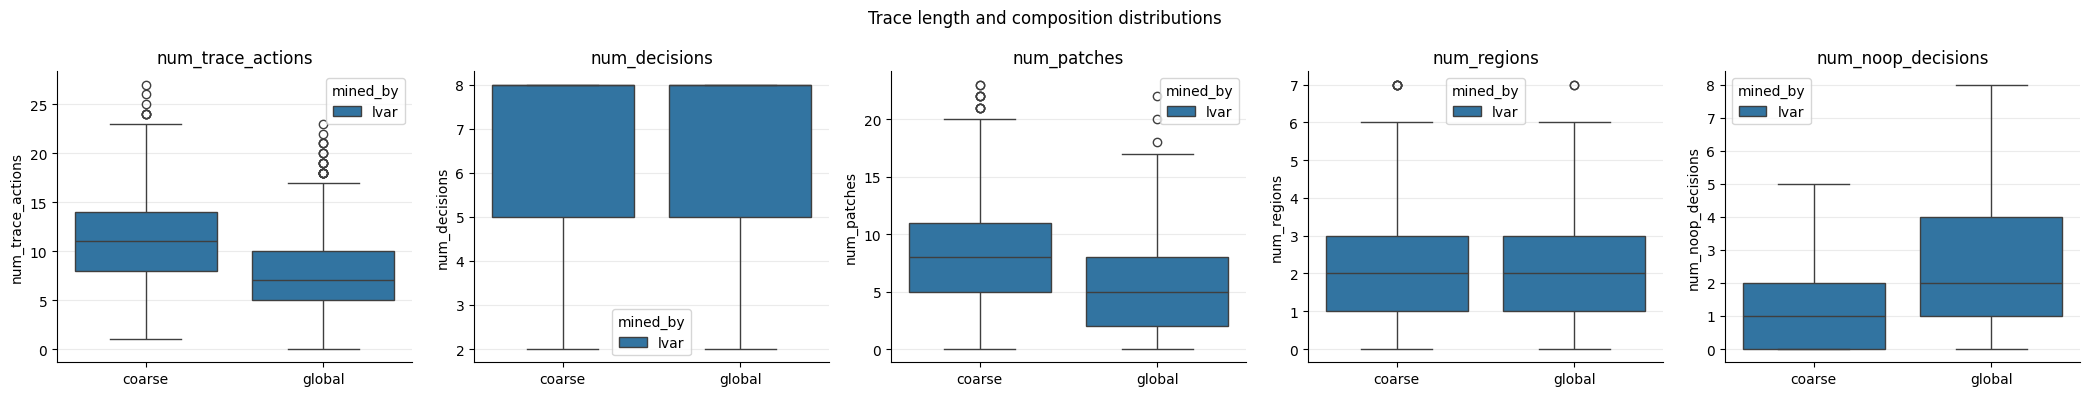

In [14]:
length_cols = ["num_trace_actions", "num_decisions", "num_patches", "num_regions", "num_noop_decisions"]
fig, axes = plt.subplots(1, len(length_cols), figsize=(4.2 * len(length_cols), 4), sharey=False)
for ax, col in zip(axes, length_cols):
    if HAS_SEABORN:
        sns.boxplot(data=trace_examples, x="context", y=col, hue="mined_by", ax=ax)
    else:
        trace_examples.boxplot(column=col, by=["mined_by", "context"], ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
fig.suptitle("Trace length and composition distributions")
plt.tight_layout()
plt.show()

## Action And Decision Distributions

Primitive actions come from the final trace sequence. High-level decisions come from the mining controller's selected decision at each reasoning step.

In [15]:
action_dist = (
    trace_actions[trace_actions["action_type"] != "STOP"]
    .groupby(["mined_by", "context", "action_type"])
    .size()
    .rename("count")
    .reset_index()
)
action_dist["share_within_trace_set"] = action_dist["count"] / action_dist.groupby(["mined_by", "context"])["count"].transform("sum")
action_pivot = action_dist.pivot_table(index=["mined_by", "context"], columns="action_type", values="share_within_trace_set", fill_value=0)
action_pivot.style.format("{:.2%}").set_caption("Primitive action distribution by trace set")

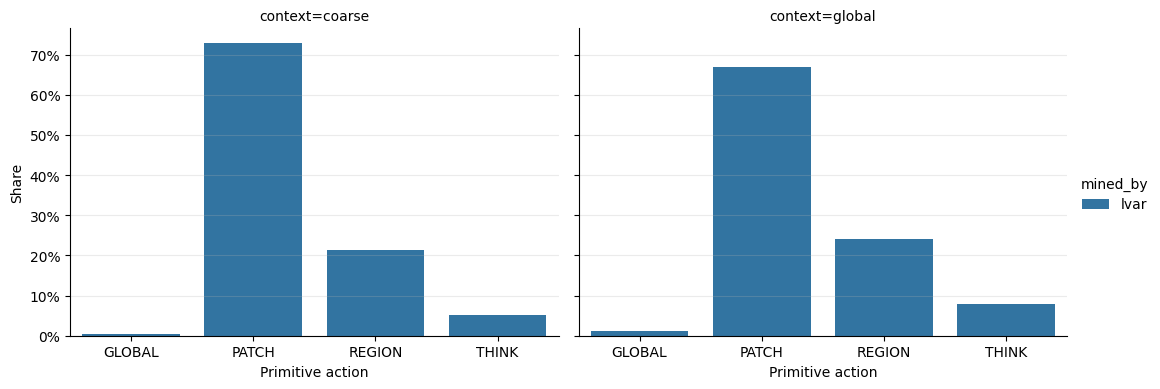

In [16]:
if HAS_SEABORN:
    g = sns.catplot(
        data=action_dist,
        kind="bar",
        x="action_type",
        y="share_within_trace_set",
        hue="mined_by",
        col="context",
        height=4,
        aspect=1.35,
    )
    g.set_axis_labels("Primitive action", "Share")
    g.set_titles("context={col_name}")
    for ax in g.axes.flat:
        ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    plt.show()
else:
    action_pivot.plot(kind="bar", figsize=(10, 5))
    plt.ylabel("Share")
    plt.tight_layout()
    plt.show()

In [17]:
decision_dist = (
    trace_decisions
    .groupby(["mined_by", "context", "selected"])
    .size()
    .rename("count")
    .reset_index()
)
decision_dist["share_within_trace_set"] = decision_dist["count"] / decision_dist.groupby(["mined_by", "context"])["count"].transform("sum")
decision_pivot = decision_dist.pivot_table(index=["mined_by", "context"], columns="selected", values="share_within_trace_set", fill_value=0)
decision_pivot.style.format("{:.2%}").set_caption("High-level selected decision distribution by trace set")

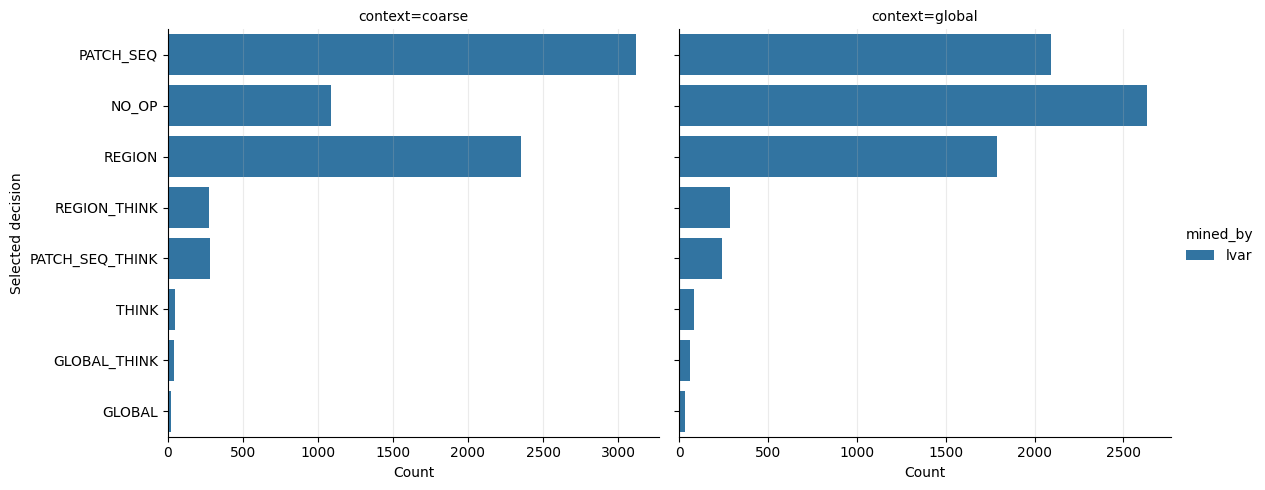

In [18]:
top_decisions = decision_dist.sort_values("count", ascending=False).head(40)
if HAS_SEABORN:
    g = sns.catplot(
        data=top_decisions,
        kind="bar",
        y="selected",
        x="count",
        hue="mined_by",
        col="context",
        height=5,
        aspect=1.2,
        sharex=False,
    )
    g.set_axis_labels("Count", "Selected decision")
    g.set_titles("context={col_name}")
    plt.show()
else:
    decision_dist.pivot_table(index="selected", columns=["mined_by", "context"], values="count", fill_value=0).plot(kind="barh", figsize=(11, 7))
    plt.tight_layout()
    plt.show()

## Selected Patches And Regions

This section shows which patch and region indices were selected most often, including heatmaps when indices form a square-ish grid. The counterfactual table compares selected positive actions against the sampled negative alternatives from mining.

In [19]:
def top_index_table(df, index_col, label, top_n=15):
    out = (
        df.dropna(subset=[index_col])
        .assign(**{index_col: lambda x: x[index_col].astype(int)})
        .groupby(["mined_by", "context", index_col])
        .size()
        .rename("count")
        .reset_index()
        .sort_values(["mined_by", "context", "count"], ascending=[True, True, False])
    )
    out["rank"] = out.groupby(["mined_by", "context"])["count"].rank(method="first", ascending=False).astype(int)
    return out[out["rank"] <= top_n].rename(columns={index_col: label})

selected_patch_top = top_index_table(trace_actions[trace_actions["action_type"] == "PATCH"], "patch_idx", "patch_idx")
selected_region_top = top_index_table(trace_actions[trace_actions["action_type"] == "REGION"], "region_idx", "region_idx")

print("Top selected patches")
display(selected_patch_top)
print("Top selected regions")
display(selected_region_top)

Top selected patches


,mined_by,context,patch_idx,count,rank
99,lvar,coarse,99,306,1
4,lvar,coarse,4,199,2
7,lvar,coarse,7,178,3
0,lvar,coarse,0,157,4
91,lvar,coarse,91,146,5
6,lvar,coarse,6,133,6
8,lvar,coarse,8,131,7
92,lvar,coarse,92,130,8
97,lvar,coarse,97,129,9
81,lvar,coarse,81,128,10


Top selected regions


,mined_by,context,region_idx,count,rank
24,lvar,coarse,24,262,1
21,lvar,coarse,21,140,2
0,lvar,coarse,0,138,3
20,lvar,coarse,20,132,4
15,lvar,coarse,15,130,5
22,lvar,coarse,22,123,6
5,lvar,coarse,5,121,7
6,lvar,coarse,6,114,8
23,lvar,coarse,23,114,9
2,lvar,coarse,2,111,10


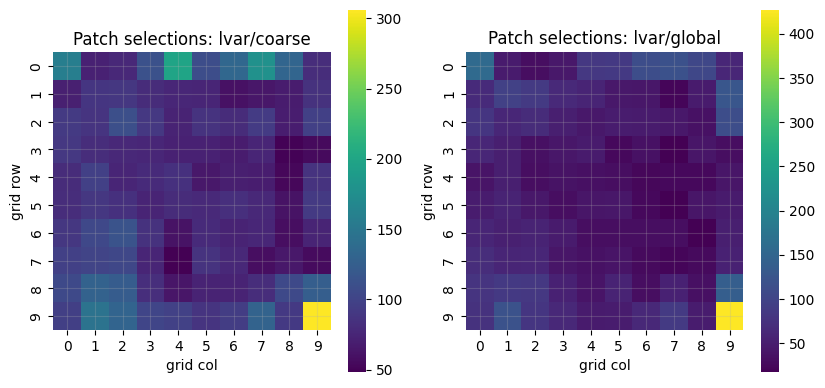

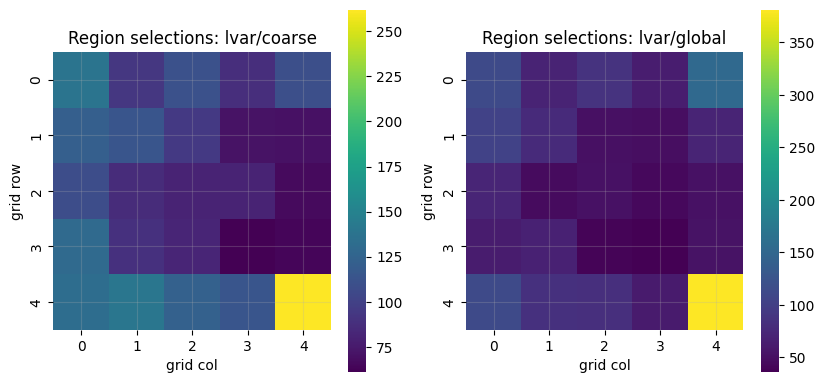

In [20]:
def plot_index_heatmaps(df, index_col, title_prefix):
    usable = df.dropna(subset=[index_col]).copy()
    if usable.empty:
        print(f"No indices available for {index_col}")
        return
    usable[index_col] = usable[index_col].astype(int)
    groups = list(usable.groupby(["mined_by", "context"]))
    fig, axes = plt.subplots(1, len(groups), figsize=(4.2 * len(groups), 4), squeeze=False)
    for ax, ((mined_by, context), group) in zip(axes.flat, groups):
        n = infer_grid_size(group[index_col].tolist())
        grid = np.zeros((n, n), dtype=float)
        counts = group[index_col].value_counts()
        for idx, count in counts.items():
            grid[int(idx) // n, int(idx) % n] = count
        if HAS_SEABORN:
            sns.heatmap(grid, ax=ax, cmap="viridis", cbar=True, square=True)
        else:
            im = ax.imshow(grid, cmap="viridis")
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(f"{title_prefix}: {mined_by}/{context}")
        ax.set_xlabel("grid col")
        ax.set_ylabel("grid row")
    plt.tight_layout()
    plt.show()

plot_index_heatmaps(trace_actions[trace_actions["action_type"] == "PATCH"], "patch_idx", "Patch selections")
plot_index_heatmaps(trace_actions[trace_actions["action_type"] == "REGION"], "region_idx", "Region selections")

In [21]:
cf_summary = (
    trace_counterfactual_actions
    .groupby(["mined_by", "context", "polarity", "action_type"])
    .size()
    .rename("count")
    .reset_index()
)
cf_summary["share"] = cf_summary["count"] / cf_summary.groupby(["mined_by", "context", "polarity"])["count"].transform("sum")
cf_summary.pivot_table(index=["mined_by", "context", "polarity"], columns="action_type", values="share", fill_value=0).style.format("{:.2%}").set_caption("Counterfactual positive vs negative action distribution")

## Cross-Entropy Reduction

`total_ce_reduction` is the sum over mined decisions of `ce_noop - ce_selected` (or the stored `improvement`). This captures the total reduction in target continuation cross entropy attributable to the selected trace decisions for an example.

In [22]:
ce_summary = (
    trace_examples
    .groupby(["mined_by", "context"])
    .agg(
        examples=("example_id", "nunique"),
        mean_total_reduction=("total_ce_reduction", "mean"),
        median_total_reduction=("total_ce_reduction", "median"),
        std_total_reduction=("total_ce_reduction", "std"),
        p10_total_reduction=("total_ce_reduction", lambda s: s.quantile(0.10)),
        p90_total_reduction=("total_ce_reduction", lambda s: s.quantile(0.90)),
        mean_step_reduction=("mean_ce_reduction", "mean"),
        mean_positive_decisions=("num_positive_decisions", "mean"),
    )
    .reset_index()
)
ce_summary.style.format({c: "{:.4f}" for c in ce_summary.columns if c not in ["mined_by", "context", "examples"]})

,mined_by,context,examples,mean_total_reduction,median_total_reduction,std_total_reduction,p10_total_reduction,p90_total_reduction,mean_step_reduction,mean_positive_decisions
0,lvar,coarse,1108,0.7482,0.6580,0.4200,0.3026,1.3103,0.1240,5.5361
1,lvar,global,1108,0.4809,0.4095,0.3015,0.1737,0.8856,0.0842,4.1408


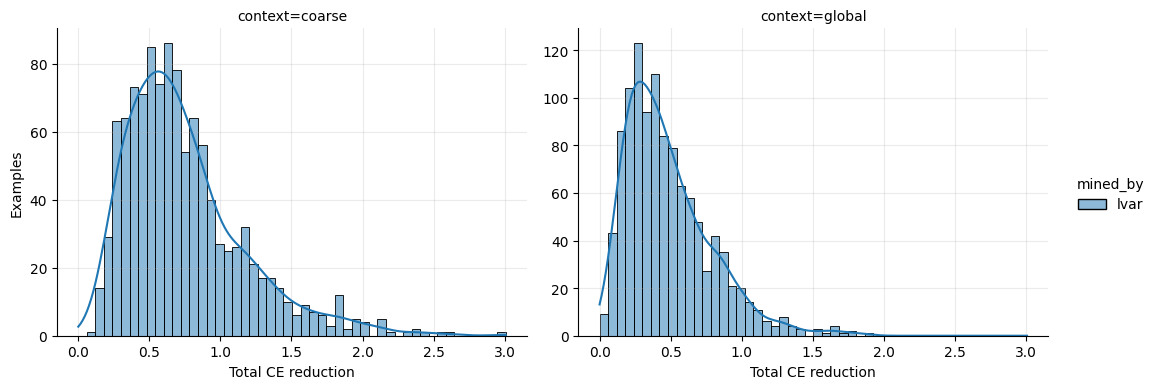

In [23]:
if HAS_SEABORN:
    g = sns.displot(
        data=trace_examples,
        x="total_ce_reduction",
        hue="mined_by",
        col="context",
        kind="hist",
        bins=50,
        kde=True,
        height=4,
        aspect=1.35,
        facet_kws={"sharex": True, "sharey": False},
    )
    g.set_axis_labels("Total CE reduction", "Examples")
    g.set_titles("context={col_name}")
    plt.show()
else:
    for (mined_by, context), group in trace_examples.groupby(["mined_by", "context"]):
        plt.hist(group["total_ce_reduction"], bins=50, alpha=0.45, label=f"{mined_by}/{context}")
    plt.xlabel("Total CE reduction")
    plt.ylabel("Examples")
    plt.legend()
    plt.show()

In [24]:
step_reduction_summary = (
    trace_decisions
    .groupby(["mined_by", "context", "selected"])
    .agg(
        decisions=("ce_reduction", "size"),
        mean_reduction=("ce_reduction", "mean"),
        median_reduction=("ce_reduction", "median"),
        positive_rate=("ce_reduction", lambda s: (s > 0).mean()),
    )
    .reset_index()
    .sort_values(["mined_by", "context", "mean_reduction"], ascending=[True, True, False])
)
step_reduction_summary.style.format({"mean_reduction": "{:.4f}", "median_reduction": "{:.4f}", "positive_rate": "{:.2%}"}).set_caption("CE reduction by selected high-level decision")

,mined_by,context,selected,decisions,mean_reduction,median_reduction,positive_rate
1,lvar,coarse,GLOBAL_THINK,41,0.2408,0.1299,100.00%
6,lvar,coarse,REGION_THINK,274,0.2377,0.1508,100.00%
4,lvar,coarse,PATCH_SEQ_THINK,279,0.2249,0.1532,100.00%
7,lvar,coarse,THINK,49,0.1877,0.1297,100.00%
0,lvar,coarse,GLOBAL,21,0.1426,0.0620,100.00%
5,lvar,coarse,REGION,2351,0.1260,0.0943,100.00%
3,lvar,coarse,PATCH_SEQ,3119,0.1228,0.0927,100.00%
2,lvar,coarse,NO_OP,1089,0.0000,0.0000,0.00%
9,lvar,global,GLOBAL_THINK,64,0.2457,0.1276,100.00%
14,lvar,global,REGION_THINK,289,0.2180,0.1271,100.00%


## 3. Correct vs Incorrect Inference Outcomes

This loads every oracle prediction JSONL plus the full LVAR model + controller predictions. Oracle outcomes are joined back to mined trace features by `(mined_by, context, example_id)`; the full run remains in the shared prediction table but naturally has no oracle-mining CE features.


In [25]:
prediction_rows = []
bad_prediction_rows = []


def append_prediction_rows(rows, metadata, output_path):
    for row in rows:
        prediction_rows.append({
            **metadata,
            "example_id": row.get("example_id"),
            "correct": bool(row.get("correct")),
            "gold_answer": row.get("gold_answer"),
            "raw_answer": row.get("raw_answer"),
            "generated_text": row.get("generated_text"),
            "decoded_answer": row.get("decoded_answer"),
            "domain": row.get("domain"),
            "topic": row.get("topic"),
            "num_inference_trace_actions": row.get("num_trace_actions") or row.get("num_steps") or row.get("num_controller_actions"),
            "num_output_tokens": row.get("num_output_tokens"),
            "controller_actions": [str(step.get("action", "UNKNOWN")).upper() for step in (row.get("trace") or [])],
            "kept_primitives": (row.get("transform") or {}).get("kept_primitives"),
            "cap_applied": (row.get("transform") or {}).get("cap_applied"),
            "prediction_path": str(output_path.relative_to(ROOT)),
        })


for summary_path in sorted(INFERENCE_ROOT.rglob("*_summary.json")):
    summary = load_json(summary_path)
    mined_by, evaluated_by, variant_from_path = parse_inference_summary_path(summary_path)
    trace_variant = summary.get("trace_variant") or variant_from_path
    mining_context, replay_context = parse_mining_and_replay_context(summary, summary_path)
    output_path = Path(summary.get("output_path", ""))
    if not output_path.is_absolute():
        output_path = ROOT / output_path
    if not output_path.exists():
        print(f"Missing prediction file: {output_path}")
        continue
    rows, bad_rows = load_jsonl(output_path)
    bad_prediction_rows.extend(bad_rows)
    append_prediction_rows(rows, {
        "run_type": "oracle",
        "mined_by": mined_by,
        "context": mining_context,
        "replay_context": replay_context,
        "evaluated_by": evaluated_by,
        "trace_variant": trace_variant,
        "trace_variant_label": pretty_variant(trace_variant),
    }, output_path)

full_lvar_predictions_path = FULL_LVAR_ROOT / "m3cot_lvar_predictions.jsonl"
if full_lvar_predictions_path.exists():
    rows, bad_rows = load_jsonl(full_lvar_predictions_path)
    bad_prediction_rows.extend(bad_rows)
    full_summary = load_json(full_lvar_summary_path) if full_lvar_summary_path.exists() else {}
    append_prediction_rows(rows, {
        "run_type": "full_lvar",
        "mined_by": "full_lvar",
        "context": "coarse" if full_summary.get("coarse_context") else "global",
        "replay_context": "coarse" if full_summary.get("coarse_context") else "global",
        "evaluated_by": "lvar+controller",
        "trace_variant": "controller_generated",
        "trace_variant_label": "controller-generated",
    }, full_lvar_predictions_path)

predictions = pd.DataFrame(prediction_rows)
print("prediction rows", predictions.shape)
print("bad prediction rows", len(bad_prediction_rows))
predictions.head()


prediction rows (21052, 21)
bad prediction rows 0


,run_type,mined_by,context,replay_context,evaluated_by,trace_variant,trace_variant_label,example_id,correct,gold_answer,raw_answer,generated_text,decoded_answer,domain,topic,num_inference_trace_actions,num_output_tokens,controller_actions,kept_primitives,cap_applied,prediction_path
0,oracle,lvar,coarse,global,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1370,False,b,B,"Therefore, the answer is C","Therefore, the answer is C",commonsense,physical-commonsense,2,6,"[REGION, STOP]",2.0,True,outputs/inference/validation_oracle/mined_by_lvar_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_validation_predictions_m...
1,oracle,lvar,coarse,global,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1409,False,d,D,"Therefore, the answer is C","Therefore, the answer is C",commonsense,physical-commonsense,6,6,"[PATCH, PATCH, PATCH, REGION, REGION, STOP]",6.0,True,outputs/inference/validation_oracle/mined_by_lvar_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_validation_predictions_m...
2,oracle,lvar,coarse,global,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1400,False,c,C,"Therefore, the answer is D","Therefore, the answer is D",commonsense,physical-commonsense,9,6,"[REGION, PATCH, PATCH, PATCH, PATCH, REGION, REGION, THINK, STOP]",9.0,True,outputs/inference/validation_oracle/mined_by_lvar_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_validation_predictions_m...
3,oracle,lvar,coarse,global,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1401,False,b,B,"Therefore, the answer is C","Therefore, the answer is C",commonsense,physical-commonsense,7,6,"[PATCH, PATCH, PATCH, REGION, REGION, THINK, STOP]",7.0,True,outputs/inference/validation_oracle/mined_by_lvar_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_validation_predictions_m...
4,oracle,lvar,coarse,global,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1388,False,c,C,"Therefore, the answer is D","Therefore, the answer is D",commonsense,physical-commonsense,9,6,"[PATCH, PATCH, PATCH, PATCH, PATCH, PATCH, PATCH, PATCH, STOP]",9.0,True,outputs/inference/validation_oracle/mined_by_lvar_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_validation_predictions_m...


In [26]:
join_cols = ["mined_by", "context", "example_id"]
trace_features = trace_examples.drop(columns=["selected_decisions", "primitive_action_types", "patch_indices", "region_indices"], errors="ignore")
correctness_traces = predictions.merge(trace_features, on=join_cols, how="left", suffixes=("_pred", "_trace"))

missing_trace_join = correctness_traces["total_ce_reduction"].isna().sum()
print(f"Joined prediction rows: {len(correctness_traces):,}")
print(f"Rows missing trace features after join: {missing_trace_join:,}")
correctness_traces.head()

Joined prediction rows: 21,052
Rows missing trace features after join: 1,108


,run_type,mined_by,context,replay_context,evaluated_by,trace_variant,trace_variant_label,example_id,correct,gold_answer,raw_answer,generated_text,decoded_answer,domain,topic,num_inference_trace_actions,num_output_tokens,controller_actions,kept_primitives,cap_applied,prediction_path,answer,num_steps,num_decisions,num_trace_actions_with_stop,num_trace_actions,num_patches,num_regions,num_think,has_stop,num_noop_decisions,num_positive_decisions,total_ce_noop,total_ce_selected,total_ce_reduction,mean_ce_reduction,max_ce_reduction,mean_decision_action_length,question
0,oracle,lvar,coarse,global,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1370,False,b,B,"Therefore, the answer is C","Therefore, the answer is C",commonsense,physical-commonsense,2,6,"[REGION, STOP]",2.0,True,outputs/inference/validation_oracle/mined_by_lvar_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_validation_predictions_m...,B,2.0,2.0,2.0,1.0,0.0,1.0,0.0,True,1.0,1.0,1.208742,0.670161,0.538581,0.269290,0.538581,0.500000,[Question]:{What is the reason for someone slicing and grabbing a pizza with their hands?}\n[Options]:\n(A).{They are trying to demonstr...
1,oracle,lvar,coarse,global,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1409,False,d,D,"Therefore, the answer is C","Therefore, the answer is C",commonsense,physical-commonsense,6,6,"[PATCH, PATCH, PATCH, REGION, REGION, STOP]",6.0,True,outputs/inference/validation_oracle/mined_by_lvar_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_validation_predictions_m...,D,4.0,4.0,11.0,10.0,7.0,2.0,1.0,True,0.0,4.0,7.955619,7.410300,0.545319,0.136330,0.192734,2.500000,[Question]:{What might be the possible function of the areay?}\n[Options]:\n(A).{Putting on makeup}\n(B).{Conducting business meetings}\...
2,oracle,lvar,coarse,global,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1400,False,c,C,"Therefore, the answer is D","Therefore, the answer is D",commonsense,physical-commonsense,9,6,"[REGION, PATCH, PATCH, PATCH, PATCH, REGION, REGION, THINK, STOP]",9.0,True,outputs/inference/validation_oracle/mined_by_lvar_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_validation_predictions_m...,C,6.0,6.0,9.0,8.0,4.0,3.0,1.0,True,2.0,4.0,12.123119,11.760068,0.363051,0.060509,0.153141,1.333333,[Question]:{Why is the man wearing an orange hat on the tennis court?}\n[Options]:\n(A).{He wants to match his outfit with his tennis sh...
3,oracle,lvar,coarse,global,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1401,False,b,B,"Therefore, the answer is C","Therefore, the answer is C",commonsense,physical-commonsense,7,6,"[PATCH, PATCH, PATCH, REGION, REGION, THINK, STOP]",7.0,True,outputs/inference/validation_oracle/mined_by_lvar_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_validation_predictions_m...,B,4.0,4.0,11.0,10.0,7.0,2.0,1.0,True,0.0,4.0,7.065436,6.577361,0.488075,0.122019,0.202386,2.500000,[Question]:{What type of door is shown in the image?}\n[Options]:\n(A).{A front door}\n(B).{A rear door}\n(C).{A screen door}\n(D).{A ga...
4,oracle,lvar,coarse,global,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1388,False,c,C,"Therefore, the answer is D","Therefore, the answer is D",commonsense,physical-commonsense,9,6,"[PATCH, PATCH, PATCH, PATCH, PATCH, PATCH, PATCH, PATCH, STOP]",9.0,True,outputs/inference/validation_oracle/mined_by_lvar_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_validation_predictions_m...,C,7.0,7.0,14.0,13.0,13.0,0.0,0.0,True,2.0,5.0,13.806279,13.180565,0.625713,0.089388,0.194808,1.857143,[Question]:{What is the likely reason for the presence of boats in the water body?}\n[Options]:\n(A).{Boats were donated to people livin...


In [27]:
correctness_summary = (
    correctness_traces
    .groupby(["mined_by", "context", "replay_context", "evaluated_by", "trace_variant_label", "correct"])
    .agg(
        examples=("example_id", "nunique"),
        mean_total_ce_reduction=("total_ce_reduction", "mean"),
        median_total_ce_reduction=("total_ce_reduction", "median"),
        mean_step_reduction=("mean_ce_reduction", "mean"),
        mean_trace_actions=("num_trace_actions", "mean"),
        mean_patches=("num_patches", "mean"),
        mean_regions=("num_regions", "mean"),
        mean_noop_decisions=("num_noop_decisions", "mean"),
        mean_inference_trace_actions=("num_inference_trace_actions", "mean"),
    )
    .reset_index()
    .sort_values(["mined_by", "context", "replay_context", "evaluated_by", "trace_variant_label", "correct"])
)
correctness_summary.style.format({
    "mean_total_ce_reduction": "{:.4f}",
    "median_total_ce_reduction": "{:.4f}",
    "mean_step_reduction": "{:.4f}",
    "mean_trace_actions": "{:.2f}",
    "mean_patches": "{:.2f}",
    "mean_regions": "{:.2f}",
    "mean_noop_decisions": "{:.2f}",
    "mean_inference_trace_actions": "{:.2f}",
}).set_caption("Mined trace statistics split by correct vs incorrect inference outcomes")

,mined_by,context,replay_context,evaluated_by,trace_variant_label,correct,examples,mean_total_ce_reduction,median_total_ce_reduction,mean_step_reduction,mean_trace_actions,mean_patches,mean_regions,mean_noop_decisions,mean_inference_trace_actions
0,full_lvar,global,global,lvar+controller,controller-generated,False,435,nan,nan,nan,nan,nan,nan,nan,7.84
1,full_lvar,global,global,lvar+controller,controller-generated,True,673,nan,nan,nan,nan,nan,nan,nan,8.00
2,lvar,coarse,coarse,ivtlr,filtered (cap),False,607,0.7815,0.6901,0.1272,11.65,8.52,2.48,0.87,8.02
3,lvar,coarse,coarse,ivtlr,filtered (cap),True,501,0.7079,0.6067,0.1201,10.43,7.58,2.23,1.12,7.60
4,lvar,coarse,coarse,ivtlr,filtered (no cap),False,596,0.7875,0.6942,0.1278,11.64,8.49,2.50,0.86,11.93
5,lvar,coarse,coarse,ivtlr,filtered (no cap),True,512,0.7024,0.6070,0.1195,10.47,7.63,2.22,1.13,10.72
6,lvar,coarse,coarse,ivtlr,raw,False,591,0.7862,0.6913,0.1278,11.63,8.49,2.49,0.86,12.63
7,lvar,coarse,coarse,ivtlr,raw,True,517,0.7047,0.6126,0.1196,10.49,7.64,2.23,1.13,11.49
8,lvar,coarse,coarse,lvar,filtered (cap),False,533,0.8037,0.7015,0.1301,12.10,8.95,2.49,0.84,8.10
9,lvar,coarse,coarse,lvar,filtered (cap),True,575,0.6967,0.5989,0.1183,10.17,7.29,2.26,1.12,7.58


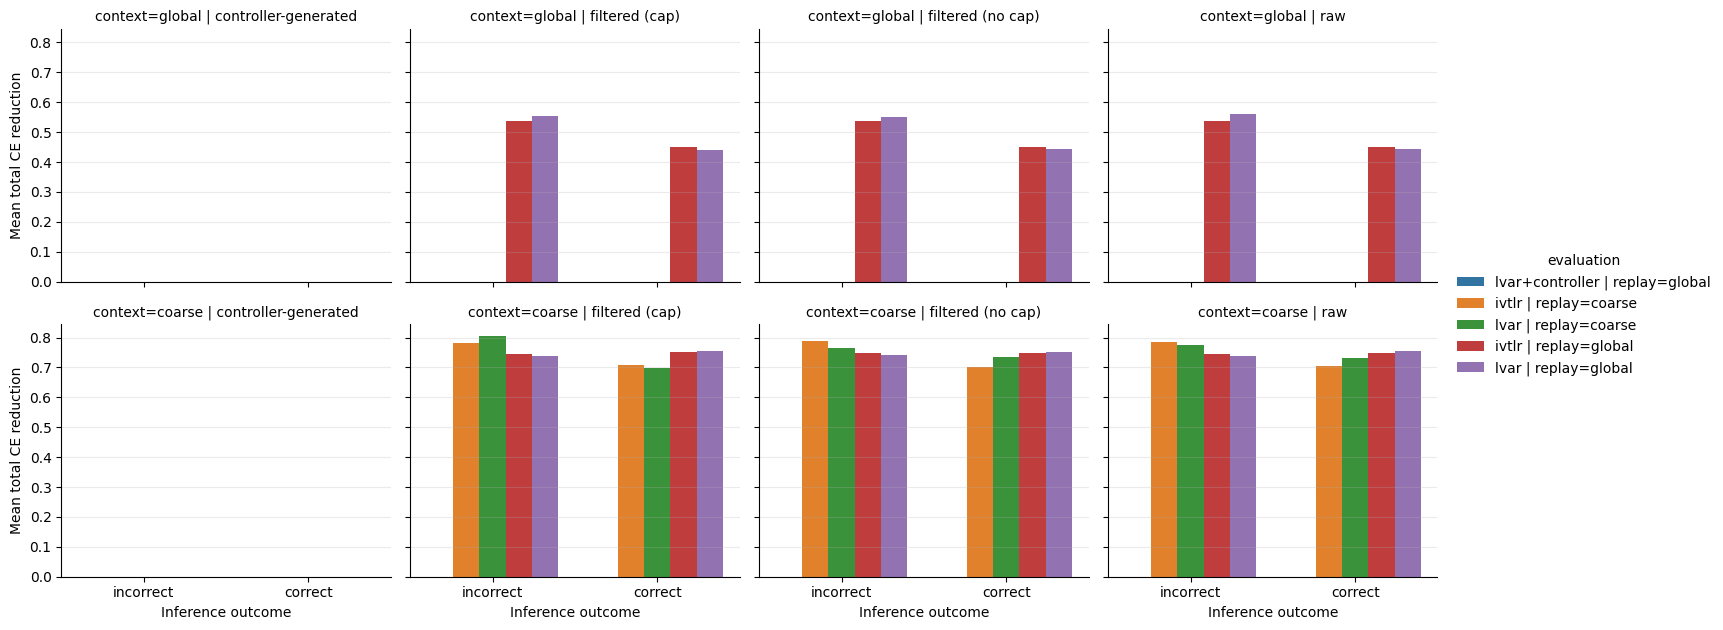

In [28]:
plot_correctness = correctness_summary.copy()
plot_correctness["outcome"] = np.where(plot_correctness["correct"], "correct", "incorrect")
plot_correctness["setting"] = (
    "mined=" + plot_correctness["mined_by"].astype(str)
    + " | eval=" + plot_correctness["evaluated_by"].astype(str)
    + " | " + plot_correctness["context"].astype(str)
    + " → " + plot_correctness["replay_context"].astype(str)
    + " | " + plot_correctness["trace_variant_label"].astype(str)
)
plot_correctness["evaluation"] = plot_correctness["evaluated_by"].astype(str) + " | replay=" + plot_correctness["replay_context"].astype(str)

if HAS_SEABORN:
    g = sns.catplot(
        data=plot_correctness,
        kind="bar",
        x="outcome",
        y="mean_total_ce_reduction",
        hue="evaluation",
        col="trace_variant_label",
        row="context",
        height=3.2,
        aspect=1.15,
        sharey=True,
    )
    g.set_axis_labels("Inference outcome", "Mean total CE reduction")
    g.set_titles(row_template="context={row_name}", col_template="{col_name}")
    plt.show()
else:
    correctness_summary.pivot_table(index=["context", "replay_context", "trace_variant_label", "correct"], columns=["mined_by", "evaluated_by"], values="mean_total_ce_reduction").plot(kind="bar", figsize=(13, 6))
    plt.ylabel("Mean total CE reduction")
    plt.tight_layout()
    plt.show()

In [29]:
# Pick one setting for a detailed correct-vs-incorrect histogram. Change these selectors as needed.
SELECT_MINED_BY = "ivtlr"
SELECT_CONTEXT = "global"
SELECT_REPLAY_CONTEXT = "global"
SELECT_EVALUATED_BY = "ivtlr"
SELECT_TRACE_VARIANT = "raw"

selected_run = correctness_traces[
    (correctness_traces["mined_by"] == SELECT_MINED_BY)
    & (correctness_traces["context"] == SELECT_CONTEXT)
    & (correctness_traces["replay_context"] == SELECT_REPLAY_CONTEXT)
    & (correctness_traces["evaluated_by"] == SELECT_EVALUATED_BY)
    & (correctness_traces["trace_variant"] == SELECT_TRACE_VARIANT)
].copy()

print(f"Selected rows: {len(selected_run):,}")
print(selected_run["correct"].value_counts(dropna=False))

if not selected_run.empty:
    if HAS_SEABORN:
        sns.histplot(data=selected_run, x="total_ce_reduction", hue="correct", bins=50, kde=True, stat="density", common_norm=False)
    else:
        for correct, group in selected_run.groupby("correct"):
            plt.hist(group["total_ce_reduction"], bins=50, alpha=0.45, density=True, label=f"correct={correct}")
        plt.legend()
    plt.title(f"Total CE reduction by correctness: mined={SELECT_MINED_BY}, eval={SELECT_EVALUATED_BY}, {SELECT_CONTEXT}, {SELECT_TRACE_VARIANT}")
    plt.xlabel("Total CE reduction")
    plt.ylabel("Density")
    plt.show()

Selected rows: 0
Series([], Name: count, dtype: int64)


## 4. Decoding Entropy Analysis

Each entropy sidecar contains one row per sample. `answer_option_entropy` is measured at the decoding step where the model emits its selected A/B/C/D answer; `decoded_token_entropy_mean`, `median`, and `max` aggregate full-vocabulary entropy across the generated answer trace. The loaders below combine oracle runs and the full LVAR model + controller run with the same placeholder metadata used above.


In [30]:
entropy_rows = []


def resolve_from_root(path_value):
    path = Path(path_value)
    return path if path.is_absolute() else ROOT / path


def append_entropy_rows(rows, metadata, entropy_path):
    for row in rows:
        entropy_rows.append({
            **metadata,
            "run_label": (
                f"{metadata['mined_by']} | {metadata['context']}→{metadata['replay_context']} | "
                f"{metadata['evaluated_by']} | {metadata['trace_variant_label']}"
            ),
            "example_id": row.get("example_id"),
            "correct": bool(row.get("correct")),
            "gold_answer": row.get("gold_answer"),
            "decoded_answer": row.get("decoded_answer"),
            "num_output_tokens": row.get("num_output_tokens"),
            "answer_option_entropy": row.get("answer_option_entropy"),
            "decoded_token_entropy_mean": row.get("decoded_token_entropy_mean"),
            "decoded_token_entropy_median": row.get("decoded_token_entropy_median"),
            "decoded_token_entropy_max": row.get("decoded_token_entropy_max"),
            "controller_action_entropy_mean": row.get("controller_action_entropy_mean"),
            "controller_action_entropy_median": row.get("controller_action_entropy_median"),
            "controller_action_entropy_max": row.get("controller_action_entropy_max"),
            "controller_region_entropy_mean": row.get("controller_region_entropy_mean"),
            "controller_region_entropy_median": row.get("controller_region_entropy_median"),
            "controller_region_entropy_max": row.get("controller_region_entropy_max"),
            "controller_patch_entropy_mean": row.get("controller_patch_entropy_mean"),
            "controller_patch_entropy_median": row.get("controller_patch_entropy_median"),
            "controller_patch_entropy_max": row.get("controller_patch_entropy_max"),
            "controller_entropy_mean": row.get("controller_entropy_mean"),
            "controller_entropy_median": row.get("controller_entropy_median"),
            "controller_entropy_max": row.get("controller_entropy_max"),
            "controller_action_entropies": row.get("controller_action_entropies"),
            "controller_region_entropies": row.get("controller_region_entropies"),
            "controller_patch_entropies": row.get("controller_patch_entropies"),
            "controller_entropies": row.get("controller_entropies"),
            "answer_option_selected_option": row.get("answer_option_selected_option"),
            "answer_option_decoded_token_index": row.get("answer_option_decoded_token_index"),
            "answer_option_probabilities": row.get("answer_option_probabilities"),
            "decoded_token_entropies": row.get("decoded_token_entropies"),
            "entropy_path": str(entropy_path.relative_to(ROOT)),
        })


for summary_path in sorted(INFERENCE_ROOT.rglob("*_summary.json")):
    summary = load_json(summary_path)
    mined_by, evaluated_by, variant_from_path = parse_inference_summary_path(summary_path)
    trace_variant = summary.get("trace_variant") or variant_from_path
    mining_context, replay_context = parse_mining_and_replay_context(summary, summary_path)
    entropy_value = summary.get("entropy_tracking_path")
    if entropy_value:
        entropy_path = resolve_from_root(entropy_value)
    else:
        prediction_path = resolve_from_root(summary.get("output_path", ""))
        entropy_path = prediction_path.with_name(f"{prediction_path.stem}_entropy_tracking.json")
    if not entropy_path.exists():
        print(f"Missing entropy sidecar: {entropy_path}")
        continue
    append_entropy_rows(load_json(entropy_path), {
        "run_type": "oracle",
        "mined_by": mined_by,
        "context": mining_context,
        "replay_context": replay_context,
        "evaluated_by": evaluated_by,
        "trace_variant": trace_variant,
        "trace_variant_label": pretty_variant(trace_variant),
    }, entropy_path)

full_lvar_entropy_path = FULL_LVAR_ROOT / "m3cot_lvar_predictions_entropy_tracking.json"
if full_lvar_entropy_path.exists():
    full_summary = load_json(full_lvar_summary_path) if full_lvar_summary_path.exists() else {}
    append_entropy_rows(load_json(full_lvar_entropy_path), {
        "run_type": "full_lvar",
        "mined_by": "full_lvar",
        "context": "coarse" if full_summary.get("coarse_context") else "global",
        "replay_context": "coarse" if full_summary.get("coarse_context") else "global",
        "evaluated_by": "lvar+controller",
        "trace_variant": "controller_generated",
        "trace_variant_label": "controller-generated",
    }, full_lvar_entropy_path)
else:
    print(f"Full LVAR entropy sidecar not found: {full_lvar_entropy_path}")

entropy_df = pd.DataFrame(entropy_rows)
entropy_metric_cols = [
    "answer_option_entropy",
    "decoded_token_entropy_mean",
    "decoded_token_entropy_median",
    "decoded_token_entropy_max",
    "controller_action_entropy_mean",
    "controller_region_entropy_mean",
    "controller_patch_entropy_mean",
    "controller_entropy_mean",
]
for col in entropy_metric_cols:
    entropy_df[col] = pd.to_numeric(entropy_df[col], errors="coerce")

print(f"Entropy rows loaded: {len(entropy_df):,}")
print(f"Runs loaded: {entropy_df['run_label'].nunique():,}")
print("Metric coverage:")
display(entropy_df[entropy_metric_cols].notna().mean().rename("fraction_present").to_frame().style.format("{:.2%}"))
entropy_df.head()


Entropy rows loaded: 21,052
Runs loaded: 19
Metric coverage:


,fraction_present
answer_option_entropy,98.16%
decoded_token_entropy_mean,99.99%
decoded_token_entropy_median,99.99%
decoded_token_entropy_max,99.99%
controller_action_entropy_mean,5.26%
controller_region_entropy_mean,5.26%
controller_patch_entropy_mean,5.26%
controller_entropy_mean,5.26%


,run_type,mined_by,context,replay_context,evaluated_by,trace_variant,trace_variant_label,run_label,example_id,correct,gold_answer,decoded_answer,num_output_tokens,answer_option_entropy,decoded_token_entropy_mean,decoded_token_entropy_median,decoded_token_entropy_max,controller_action_entropy_mean,controller_action_entropy_median,controller_action_entropy_max,controller_region_entropy_mean,controller_region_entropy_median,controller_region_entropy_max,controller_patch_entropy_mean,controller_patch_entropy_median,controller_patch_entropy_max,controller_entropy_mean,controller_entropy_median,controller_entropy_max,controller_action_entropies,controller_region_entropies,controller_patch_entropies,controller_entropies,answer_option_selected_option,answer_option_decoded_token_index,answer_option_probabilities,decoded_token_entropies,entropy_path
0,oracle,lvar,coarse,global,ivtlr,filtered_cap,filtered (cap),lvar | coarse→global | ivtlr | filtered (cap),physical-commonsense-1370,False,b,"Therefore, the answer is C",6,1.346217,0.134976,0.000007,0.808474,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,C,5.0,"{'A': 0.18772868812084198, 'B': 0.2349335253238678, 'C': 0.37370482087135315, 'D': 0.20363298058509827}","[0.0013580728555098176, 2.7851970116898883e-06, 6.89880425852607e-06, 7.516357982240152e-06, 4.566682946460787e-06, 0.8084744215011597]",outputs/inference/validation_oracle/mined_by_lvar_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_validation_predictions_m...
1,oracle,lvar,coarse,global,ivtlr,filtered_cap,filtered (cap),lvar | coarse→global | ivtlr | filtered (cap),physical-commonsense-1409,False,d,"Therefore, the answer is C",6,1.268331,0.002042,0.000019,0.011217,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,C,5.0,"{'A': 0.1748829334974289, 'B': 0.1748923808336258, 'C': 0.4753373861312866, 'D': 0.17488722503185272}","[0.011217290535569191, 3.2881157494557556e-06, 1.6298668015224393e-06, 2.6437241103849374e-05, 1.0776535418699495e-05, 0.0009916772833094]",outputs/inference/validation_oracle/mined_by_lvar_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_validation_predictions_m...
2,oracle,lvar,coarse,global,ivtlr,filtered_cap,filtered (cap),lvar | coarse→global | ivtlr | filtered (cap),physical-commonsense-1400,False,c,"Therefore, the answer is D",6,1.275291,0.018208,0.000008,0.108473,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,D,5.0,"{'A': 0.17603899538516998, 'B': 0.17611557245254517, 'C': 0.17959283292293549, 'D': 0.46825262904167175}","[0.0007590291788801551, 4.2960672885783424e-07, 2.0867157672910253e-06, 1.1530148185556754e-05, 4.358852493169252e-06, 0.10847260057926178]",outputs/inference/validation_oracle/mined_by_lvar_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_validation_predictions_m...
3,oracle,lvar,coarse,global,ivtlr,filtered_cap,filtered (cap),lvar | coarse→global | ivtlr | filtered (cap),physical-commonsense-1401,False,b,"Therefore, the answer is C",6,1.276444,0.020027,0.000012,0.119674,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,C,5.0,"{'A': 0.17622460424900055, 'B': 0.18053138256072998, 'C': 0.46705105900764465, 'D': 0.17619295418262482}","[0.0004607466689776629, 7.451858152762725e-08, 2.20649621951452e-06, 1.8847425963031128e-05, 4.667284883907996e-06, 0.11967353522777557]",outputs/inference/validation_oracle/mined_by_lvar_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_validation_predictions_m...
4,oracle,lvar,coarse,global,ivtlr,filtered_cap,filtered (cap),lvar | coarse→global | ivtlr | filtered (cap),physical-commonsense-1388,False,c,"Therefore, the answer is D",6,1.292487,0.057140,0.000024,0.325146,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,D,5.0,"{'A': 0.17980793118476868, 'B': 0.18983569741249084, 'C': 0.1806672215461731, 'D': 0.4496890902519226}","[0.017630649730563164, 1.818815690057818e-05, 2.925077978943591e-06, 2.927587775047

In [31]:
entropy_summary = (
    entropy_df
    .groupby(["run_type", "mined_by", "context", "replay_context", "evaluated_by", "trace_variant_label", "correct"], dropna=False)
    .agg(
        samples=("example_id", "size"),
        option_entropy_available=("answer_option_entropy", "count"),
        mean_option_entropy=("answer_option_entropy", "mean"),
        median_option_entropy=("answer_option_entropy", "median"),
        mean_answer_entropy=("decoded_token_entropy_mean", "mean"),
        median_answer_entropy=("decoded_token_entropy_mean", "median"),
        mean_peak_token_entropy=("decoded_token_entropy_max", "mean"),
        mean_controller_action_entropy=("controller_action_entropy_mean", "mean"),
        mean_controller_region_entropy=("controller_region_entropy_mean", "mean"),
        mean_controller_patch_entropy=("controller_patch_entropy_mean", "mean"),
        mean_controller_entropy=("controller_entropy_mean", "mean"),
        mean_output_tokens=("num_output_tokens", "mean"),
    )
    .reset_index()
)
entropy_summary["option_entropy_coverage"] = entropy_summary["option_entropy_available"] / entropy_summary["samples"]
entropy_summary.style.format({
    "option_entropy_coverage": "{:.2%}",
    "mean_option_entropy": "{:.4f}",
    "median_option_entropy": "{:.4f}",
    "mean_answer_entropy": "{:.4f}",
    "median_answer_entropy": "{:.4f}",
    "mean_peak_token_entropy": "{:.4f}",
    "mean_controller_action_entropy": "{:.4f}",
    "mean_controller_region_entropy": "{:.4f}",
    "mean_controller_patch_entropy": "{:.4f}",
    "mean_controller_entropy": "{:.4f}",
    "mean_output_tokens": "{:.2f}",
}).set_caption("Entropy metrics split by correctness for every run")


,run_type,mined_by,context,replay_context,evaluated_by,trace_variant_label,correct,samples,option_entropy_available,mean_option_entropy,median_option_entropy,mean_answer_entropy,median_answer_entropy,mean_peak_token_entropy,mean_controller_action_entropy,mean_controller_region_entropy,mean_controller_patch_entropy,mean_controller_entropy,mean_output_tokens,option_entropy_coverage
0,full_lvar,full_lvar,global,global,lvar+controller,controller-generated,False,435,417,1.3137,1.3034,0.1693,0.1216,0.8331,0.6735,2.5356,3.7214,0.6735,7.22,95.86%
1,full_lvar,full_lvar,global,global,lvar+controller,controller-generated,True,673,664,1.2829,1.2684,0.0729,0.0134,0.3728,0.6463,2.5297,3.7120,0.6463,6.28,98.66%
2,oracle,lvar,coarse,coarse,ivtlr,filtered (cap),False,607,599,1.3378,1.3489,0.1286,0.1373,0.7555,nan,nan,nan,nan,6.00,98.68%
3,oracle,lvar,coarse,coarse,ivtlr,filtered (cap),True,501,493,1.3140,1.3079,0.0862,0.0777,0.4989,nan,nan,nan,nan,6.00,98.40%
4,oracle,lvar,coarse,coarse,ivtlr,filtered (no cap),False,596,588,1.3380,1.3501,0.1282,0.1357,0.7547,nan,nan,nan,nan,6.00,98.66%
5,oracle,lvar,coarse,coarse,ivtlr,filtered (no cap),True,512,505,1.3133,1.3070,0.0833,0.0754,0.4849,nan,nan,nan,nan,6.00,98.63%
6,oracle,lvar,coarse,coarse,ivtlr,raw,False,591,582,1.3378,1.3484,0.1276,0.1341,0.7525,nan,nan,nan,nan,6.00,98.48%
7,oracle,lvar,coarse,coarse,ivtlr,raw,True,517,510,1.3131,1.3063,0.0820,0.0740,0.4793,nan,nan,nan,nan,6.00,98.65%
8,oracle,lvar,coarse,coarse,lvar,filtered (cap),False,533,522,1.3253,1.3311,0.1639,0.1294,0.8190,nan,nan,nan,nan,6.80,97.94%
9,oracle,lvar,coarse,coarse,lvar,filtered (cap),True,575,572,1.2997,1.2763,0.1146,0.0850,0.5938,nan,nan,nan,nan,6.32,99.48%


### Correct vs Incorrect Entropy Histograms

The default selection is the full LVAR pipeline. Change the four selectors to inspect an oracle run. The left panel shows uncertainty among A/B/C/D at answer selection; the right panel shows mean full-vocabulary entropy across all decoded tokens.


Selected entropy rows: 1,108


answer_option_entropy                               decoded_token_entropy_mean                               decoded_token_entropy_median                                \
                        count      mean    median       std                      count      mean    median       std                        count      mean    median       std   
correct                                                                                                                                                                           
False                     417  1.313676  1.303355  0.041790                        435  0.169337  0.121600  0.250039                          435  0.025056  0.000013  0.198001   
True                      664  1.282899  1.268383  0.029615                        673  0.072932  0.013366  0.153864                          673  0.007886  0.000016  0.109018   

        decoded_token_entropy_max                               controller_action_entropy_mean                               controller_region_entropy_mean                      \
                            count      mean    median       std                          count      mean    median       std                          count      mean    median   
correct                                                                                                                                                                           
False                         435  0.833123  0.642019  0.982587                            435  0.673479  0.674149  0.119847                            435  2.535605  2.544248   
True                          673  0.372832  0.069683  0.616812                            673  0.646264  0.640969  0.117742                            673  2.529722  2.535037   

                  controller_patch_entropy_mean                               controller_entropy_mean                                
              std                         count      mean    median       std                   count      mean    median       std  
correct                                                                                                                              
False    0.152733                           435  3.721436  3.732179  0.204452                     435  0.673479  0.674149  0.119847  
True     0.150525                           673  3.711996  3.738937  0.217901                     673  0.646264  0.640969  0.117742

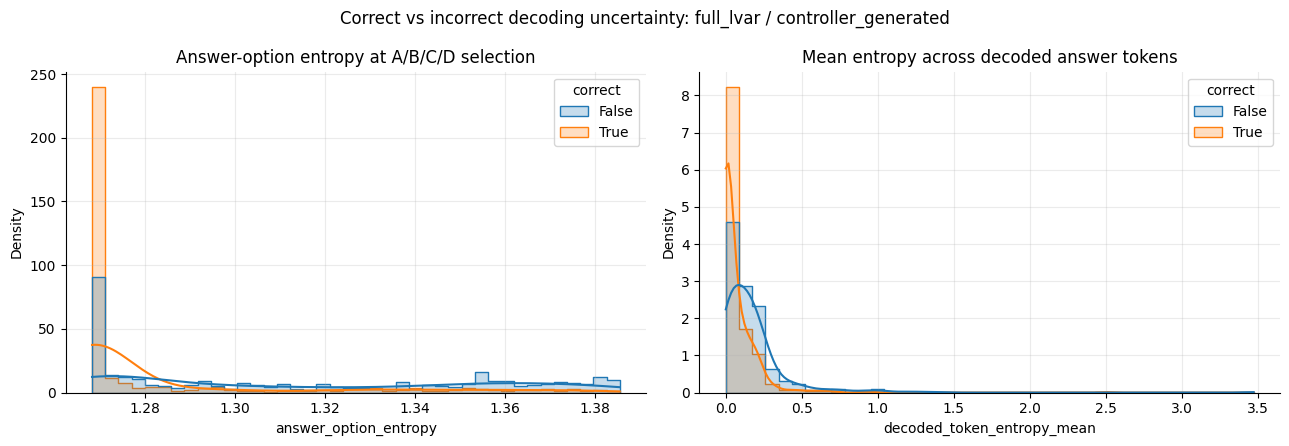

In [32]:
ENTROPY_SELECT_MINED_BY = "full_lvar"
ENTROPY_SELECT_CONTEXT = "global"
ENTROPY_SELECT_REPLAY_CONTEXT = "global"
ENTROPY_SELECT_EVALUATED_BY = "lvar+controller"
ENTROPY_SELECT_TRACE_VARIANT = "controller_generated"

selected_entropy_run = entropy_df[
    (entropy_df["mined_by"] == ENTROPY_SELECT_MINED_BY)
    & (entropy_df["context"] == ENTROPY_SELECT_CONTEXT)
    & (entropy_df["replay_context"] == ENTROPY_SELECT_REPLAY_CONTEXT)
    & (entropy_df["evaluated_by"] == ENTROPY_SELECT_EVALUATED_BY)
    & (entropy_df["trace_variant"] == ENTROPY_SELECT_TRACE_VARIANT)
].copy()

print(f"Selected entropy rows: {len(selected_entropy_run):,}")
display(selected_entropy_run.groupby("correct")[entropy_metric_cols].agg(["count", "mean", "median", "std"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
hist_specs = [
    ("answer_option_entropy", "Answer-option entropy at A/B/C/D selection"),
    ("decoded_token_entropy_mean", "Mean entropy across decoded answer tokens"),
]
for ax, (metric, title) in zip(axes, hist_specs):
    usable = selected_entropy_run.dropna(subset=[metric])
    if HAS_SEABORN:
        sns.histplot(
            data=usable,
            x=metric,
            hue="correct",
            bins=40,
            kde=True,
            stat="density",
            common_norm=False,
            element="step",
            ax=ax,
        )
    else:
        for correct, group in usable.groupby("correct"):
            ax.hist(group[metric], bins=40, alpha=0.45, density=True, label=f"correct={correct}")
        ax.legend()
    ax.set_title(title)
    ax.set_xlabel(metric)
    ax.set_ylabel("Density")
plt.suptitle(f"Correct vs incorrect decoding uncertainty: {ENTROPY_SELECT_MINED_BY} / {ENTROPY_SELECT_TRACE_VARIANT}")
plt.tight_layout()
plt.show()


### Does Higher Entropy Predict Errors?

For each run, the table reports the incorrect-minus-correct mean entropy gap and a rank AUC. AUC is defined here as the probability that a randomly chosen incorrect sample has higher entropy than a randomly chosen correct sample. `0.5` means no separation; values above `0.5` mean entropy tends to be higher for errors.


In [33]:
def error_detection_auc(frame, metric):
    usable = frame[[metric, "correct"]].dropna()
    if usable["correct"].nunique() < 2:
        return np.nan
    scores = usable[metric]
    error = (~usable["correct"]).astype(int)
    n_error = int(error.sum())
    n_correct = int((1 - error).sum())
    ranks = scores.rank(method="average")
    return float((ranks[error == 1].sum() - n_error * (n_error + 1) / 2) / (n_error * n_correct))


discrimination_rows = []
for run_label, group in entropy_df.groupby("run_label"):
    metadata = group.iloc[0]
    row = {
        "run_type": metadata["run_type"],
        "mined_by": metadata["mined_by"],
        "context": metadata["context"],
        "replay_context": metadata["replay_context"],
        "evaluated_by": metadata["evaluated_by"],
        "trace_variant_label": metadata["trace_variant_label"],
        "samples": len(group),
        "accuracy": group["correct"].mean(),
    }
    for metric in [
        "answer_option_entropy",
        "decoded_token_entropy_mean",
        "decoded_token_entropy_max",
        "controller_action_entropy_mean",
        "controller_region_entropy_mean",
        "controller_patch_entropy_mean",
        "controller_entropy_mean",
    ]:
        means = group.groupby("correct")[metric].mean()
        row[f"{metric}_error_gap"] = means.get(False, np.nan) - means.get(True, np.nan)
        row[f"{metric}_error_auc"] = error_detection_auc(group, metric)
    discrimination_rows.append(row)

entropy_discrimination = pd.DataFrame(discrimination_rows).sort_values(
    ["run_type", "mined_by", "context", "replay_context", "evaluated_by", "trace_variant_label"]
)
entropy_discrimination.style.format({
    "accuracy": "{:.2%}",
    **{c: "{:.4f}" for c in entropy_discrimination.columns if c.endswith("_gap") or c.endswith("_auc")},
}).set_caption("How strongly each entropy metric separates incorrect from correct samples")


,run_type,mined_by,context,replay_context,evaluated_by,trace_variant_label,samples,accuracy,answer_option_entropy_error_gap,answer_option_entropy_error_auc,decoded_token_entropy_mean_error_gap,decoded_token_entropy_mean_error_auc,decoded_token_entropy_max_error_gap,decoded_token_entropy_max_error_auc,controller_action_entropy_mean_error_gap,controller_action_entropy_mean_error_auc,controller_region_entropy_mean_error_gap,controller_region_entropy_mean_error_auc,controller_patch_entropy_mean_error_gap,controller_patch_entropy_mean_error_auc,controller_entropy_mean_error_gap,controller_entropy_mean_error_auc
0,full_lvar,full_lvar,global,global,lvar+controller,controller-generated,1108,60.74%,0.0308,0.7932,0.0964,0.7245,0.4603,0.7186,0.0272,0.5646,0.0059,0.5119,0.0094,0.5062,0.0272,0.5646
1,oracle,lvar,coarse,coarse,ivtlr,filtered (cap),1108,45.22%,0.0238,0.6737,0.0424,0.6745,0.2565,0.6760,nan,nan,nan,nan,nan,nan,nan,nan
2,oracle,lvar,coarse,coarse,ivtlr,filtered (no cap),1108,46.21%,0.0247,0.6801,0.0449,0.6799,0.2699,0.6827,nan,nan,nan,nan,nan,nan,nan,nan
3,oracle,lvar,coarse,coarse,ivtlr,raw,1108,46.66%,0.0247,0.6821,0.0457,0.6826,0.2732,0.6855,nan,nan,nan,nan,nan,nan,nan,nan
4,oracle,lvar,coarse,coarse,lvar,filtered (cap),1108,51.90%,0.0256,0.6963,0.0493,0.6268,0.2252,0.6293,nan,nan,nan,nan,nan,nan,nan,nan
5,oracle,lvar,coarse,coarse,lvar,filtered (no cap),1108,58.03%,0.0293,0.7180,0.0447,0.6590,0.2307,0.6600,nan,nan,nan,nan,nan,nan,nan,nan
6,oracle,lvar,coarse,coarse,lvar,raw,1108,59.93%,0.0302,0.7217,0.0459,0.6838,0.2553,0.6838,nan,nan,nan,nan,nan,nan,nan,nan
7,oracle,lvar,coarse,global,ivtlr,filtered (cap),1108,64.62%,0.0396,0.8045,0.0799,0.8032,0.4649,0.8041,nan,nan,nan,nan,nan,nan,nan,nan
8,oracle,lvar,coarse,global,ivtlr,filtered (no cap),1108,64.62%,0.0391,0.8020,0.0754,0.7971,0.4406,0.7981,nan,nan,nan,nan,nan,nan,nan,nan
9,oracle,lvar,coarse,global,ivtlr,raw,1108,64.71%,0.0391,0.8018,0.0729,0.7971,0.4302,0.7976,nan,nan,nan,nan,nan,nan,nan,nan


### Accuracy Across Entropy Quantiles

This is a calibration-style view for the selected run. Samples are divided into entropy quintiles independently for each metric; a useful uncertainty signal should generally show lower accuracy in higher-entropy bins.


,entropy_quantile,samples,accuracy,mean_entropy,metric,quantile_rank
0,"(1.26829, 1.26832]",220,96.82%,1.2683,answer_option_entropy,1
1,"(1.26832, 1.26853]",213,77.93%,1.2684,answer_option_entropy,2
2,"(1.26853, 1.27726]",216,57.87%,1.2708,answer_option_entropy,3
3,"(1.27726, 1.33695]",216,43.52%,1.3039,answer_option_entropy,4
4,"(1.33695, 1.38555]",216,30.56%,1.3626,answer_option_entropy,5
5,"(-0.0009882, 0.00127]",222,87.39%,0.0004,decoded_token_entropy_mean,1
6,"(0.00127, 0.0172]",221,73.76%,0.0066,decoded_token_entropy_mean,2
7,"(0.0172, 0.0914]",222,59.46%,0.0501,decoded_token_entropy_mean,3
8,"(0.0914, 0.186]",221,47.51%,0.1350,decoded_token_entropy_mean,4
9,"(0.186, 3.473]",222,35.59%,0.3615,decoded_token_entropy_mean,5


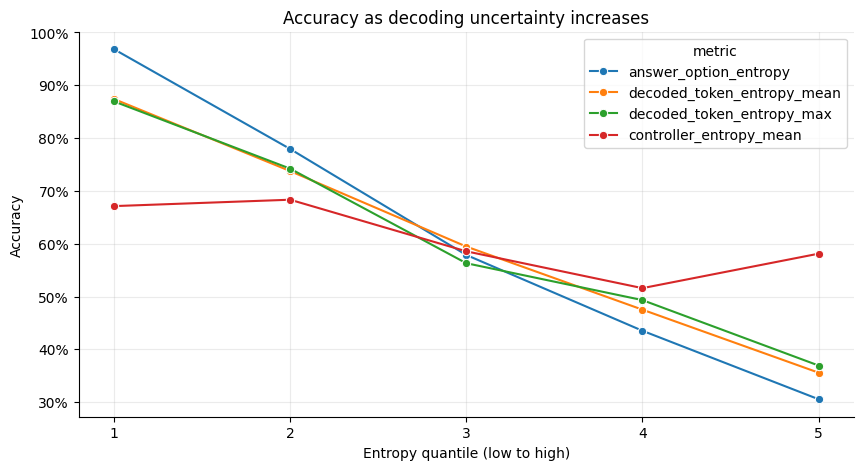

In [34]:
quantile_rows = []
for metric in [
    "answer_option_entropy",
    "decoded_token_entropy_mean",
    "decoded_token_entropy_max",
    "controller_entropy_mean",
]:
    usable = selected_entropy_run.dropna(subset=[metric]).copy()
    if usable[metric].nunique() < 2:
        continue
    usable["entropy_quantile"] = pd.qcut(usable[metric], q=min(5, usable[metric].nunique()), duplicates="drop")
    grouped = usable.groupby("entropy_quantile", observed=True).agg(
        samples=("example_id", "size"),
        accuracy=("correct", "mean"),
        mean_entropy=(metric, "mean"),
    ).reset_index()
    grouped["metric"] = metric
    grouped["entropy_quantile"] = grouped["entropy_quantile"].astype(str)
    grouped["quantile_rank"] = range(1, len(grouped) + 1)
    quantile_rows.append(grouped)

entropy_quantiles = pd.concat(quantile_rows, ignore_index=True) if quantile_rows else pd.DataFrame()
display(entropy_quantiles.style.format({"accuracy": "{:.2%}", "mean_entropy": "{:.4f}"}))

if not entropy_quantiles.empty:
    if HAS_SEABORN:
        sns.lineplot(data=entropy_quantiles, x="quantile_rank", y="accuracy", hue="metric", marker="o")
    else:
        for metric, group in entropy_quantiles.groupby("metric"):
            plt.plot(group["quantile_rank"], group["accuracy"], marker="o", label=metric)
        plt.legend()
    plt.gca().yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    plt.xticks(sorted(entropy_quantiles["quantile_rank"].unique()))
    plt.xlabel("Entropy quantile (low to high)")
    plt.ylabel("Accuracy")
    plt.title("Accuracy as decoding uncertainty increases")
    plt.show()


### Option Entropy vs Answer-Trace Entropy

The scatter plot checks whether uncertainty at final answer selection agrees with uncertainty accumulated throughout decoding. Correctness coloring can reveal distinct failure modes, such as a confident final option following a highly uncertain reasoning trace.


Spearman correlation: 0.7218


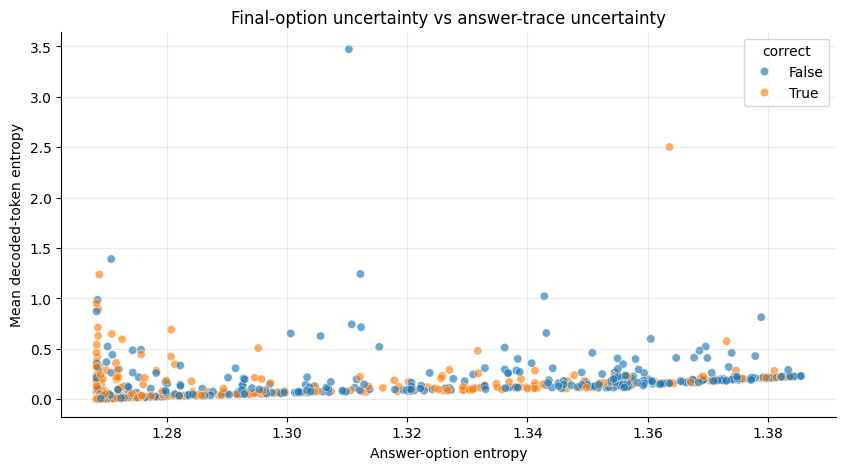

In [35]:
scatter_run = selected_entropy_run.dropna(subset=["answer_option_entropy", "decoded_token_entropy_mean"])
if scatter_run.empty:
    print("No samples have both option and answer-trace entropy for the selected run.")
else:
    correlation = scatter_run[["answer_option_entropy", "decoded_token_entropy_mean"]].corr(method="spearman").iloc[0, 1]
    print(f"Spearman correlation: {correlation:.4f}")
    if HAS_SEABORN:
        sns.scatterplot(
            data=scatter_run,
            x="answer_option_entropy",
            y="decoded_token_entropy_mean",
            hue="correct",
            alpha=0.65,
        )
    else:
        for correct, group in scatter_run.groupby("correct"):
            plt.scatter(group["answer_option_entropy"], group["decoded_token_entropy_mean"], alpha=0.65, label=f"correct={correct}")
        plt.legend()
    plt.xlabel("Answer-option entropy")
    plt.ylabel("Mean decoded-token entropy")
    plt.title("Final-option uncertainty vs answer-trace uncertainty")
    plt.show()


### Controller Entropy in the Full LVAR Pipeline

The controller emits action, region, and patch distributions at every reasoning step. The joint entropy is `H(action) + P(REGION) H(region) + P(PATCH) H(patch)`, which is the entropy of the hierarchical controller decision rather than an unweighted average of differently sized heads. The following analyses ask whether controller uncertainty separates errors, where in the trace uncertainty appears, and whether it varies by action, trace length, or domain.


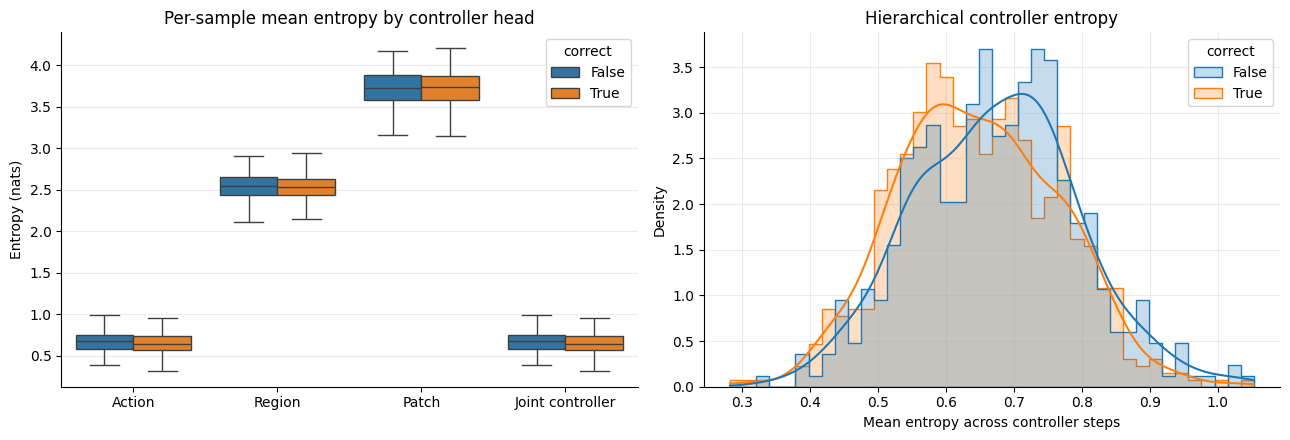

In [36]:
controller_metric_map = {
    "Action": "controller_action_entropy_mean",
    "Region": "controller_region_entropy_mean",
    "Patch": "controller_patch_entropy_mean",
    "Joint controller": "controller_entropy_mean",
}
controller_entropy_run = selected_entropy_run.dropna(subset=["controller_entropy_mean"]).copy()

if controller_entropy_run.empty:
    print("No controller entropy is available for the selected run. Rerun full LVAR inference with controller entropy tracking enabled.")
else:
    controller_long = controller_entropy_run.melt(
        id_vars=["example_id", "correct"],
        value_vars=list(controller_metric_map.values()),
        var_name="metric",
        value_name="entropy",
    )
    controller_long["head"] = controller_long["metric"].map({v: k for k, v in controller_metric_map.items()})
    controller_correctness_summary = (
        controller_long.groupby(["head", "correct"])["entropy"]
        .agg(["count", "mean", "median", "std", lambda s: s.quantile(0.10), lambda s: s.quantile(0.90)])
        .rename(columns={"<lambda_0>": "p10", "<lambda_1>": "p90"})
    )
    display(controller_correctness_summary.style.format({c: "{:.4f}" for c in ["mean", "median", "std", "p10", "p90"]}))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    if HAS_SEABORN:
        sns.boxplot(data=controller_long, x="head", y="entropy", hue="correct", showfliers=False, ax=axes[0])
        sns.histplot(
            data=controller_entropy_run,
            x="controller_entropy_mean",
            hue="correct",
            bins=40,
            kde=True,
            stat="density",
            common_norm=False,
            element="step",
            ax=axes[1],
        )
    else:
        controller_long.pivot_table(index="example_id", columns=["head", "correct"], values="entropy").boxplot(ax=axes[0], rot=30)
        for correct, group in controller_entropy_run.groupby("correct"):
            axes[1].hist(group["controller_entropy_mean"], bins=40, alpha=0.45, density=True, label=f"correct={correct}")
        axes[1].legend()
    axes[0].set_title("Per-sample mean entropy by controller head")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Entropy (nats)")
    axes[1].set_title("Hierarchical controller entropy")
    axes[1].set_xlabel("Mean entropy across controller steps")
    axes[1].set_ylabel("Density")
    plt.tight_layout()
    plt.show()


#### Error Detection and Entropy Quantiles

The AUC below treats higher entropy as evidence of an error. It is the probability that a randomly chosen incorrect sample has higher entropy than a randomly chosen correct sample. The quantile plot complements AUC by showing whether accuracy degrades monotonically as controller uncertainty rises.


,head,incorrect_minus_correct_mean,error_detection_auc,coverage
0,Action,0.0272,0.5646,100.00%
1,Region,0.0059,0.5119,100.00%
2,Patch,0.0094,0.5062,100.00%
3,Joint controller,0.0272,0.5646,100.00%


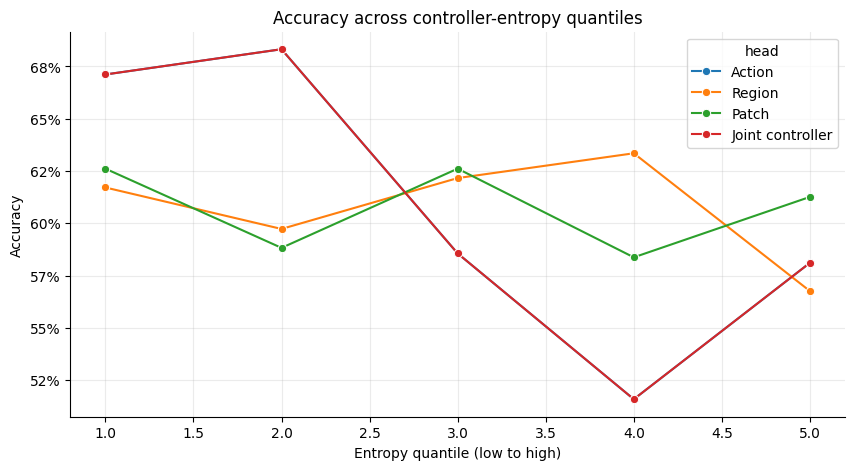

In [37]:
if not controller_entropy_run.empty:
    controller_detection_rows = []
    for label, metric in controller_metric_map.items():
        means = controller_entropy_run.groupby("correct")[metric].mean()
        controller_detection_rows.append({
            "head": label,
            "incorrect_minus_correct_mean": means.get(False, np.nan) - means.get(True, np.nan),
            "error_detection_auc": error_detection_auc(controller_entropy_run, metric),
            "coverage": controller_entropy_run[metric].notna().mean(),
        })
    controller_detection = pd.DataFrame(controller_detection_rows)
    display(controller_detection.style.format({
        "incorrect_minus_correct_mean": "{:.4f}",
        "error_detection_auc": "{:.4f}",
        "coverage": "{:.2%}",
    }))

    controller_quantile_rows = []
    for label, metric in controller_metric_map.items():
        usable = controller_entropy_run.dropna(subset=[metric]).copy()
        if usable[metric].nunique() < 2:
            continue
        usable["entropy_quantile"] = pd.qcut(usable[metric], q=min(5, usable[metric].nunique()), duplicates="drop")
        grouped = usable.groupby("entropy_quantile", observed=True).agg(
            samples=("example_id", "size"),
            accuracy=("correct", "mean"),
            mean_entropy=(metric, "mean"),
        ).reset_index()
        grouped["head"] = label
        grouped["quantile_rank"] = range(1, len(grouped) + 1)
        controller_quantile_rows.append(grouped)
    controller_entropy_quantiles = pd.concat(controller_quantile_rows, ignore_index=True)

    if HAS_SEABORN:
        sns.lineplot(data=controller_entropy_quantiles, x="quantile_rank", y="accuracy", hue="head", marker="o")
    else:
        for head, group in controller_entropy_quantiles.groupby("head"):
            plt.plot(group["quantile_rank"], group["accuracy"], marker="o", label=head)
        plt.legend()
    plt.gca().yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    plt.xlabel("Entropy quantile (low to high)")
    plt.ylabel("Accuracy")
    plt.title("Accuracy across controller-entropy quantiles")
    plt.show()


#### Entropy Through the Controller Trace

This expands each sample into controller steps. It compares uncertainty trajectories for correct and incorrect examples and separates the result by the action selected at that step. A rising error-only trajectory can indicate late indecision; a high first-step gap points instead to uncertainty in initial visual planning.


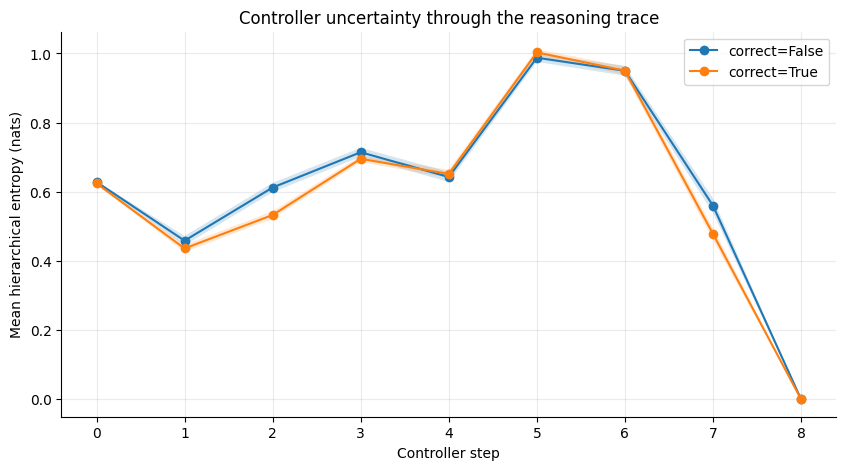

,action,correct,steps,action_entropy,region_entropy,patch_entropy,selected_index_entropy,joint_entropy
0,PATCH,False,1698,0.7280,2.7273,3.8197,3.8197,0.7280
1,PATCH,True,2831,0.6958,2.7293,3.8326,3.8326,0.6958
2,REGION,False,951,0.6472,2.7448,3.8845,2.7448,0.6472
3,REGION,True,1340,0.6681,2.7882,3.9576,2.7882,0.6681
4,STOP,False,435,0.4232,1.2933,2.9816,nan,0.4232
5,STOP,True,673,0.3095,1.1664,2.7733,nan,0.3095
6,THINK,False,326,0.7618,2.5078,3.6980,nan,0.7618
7,THINK,True,539,0.7308,2.4598,3.6140,nan,0.7308


In [38]:
controller_action_lookup = (
    predictions[predictions["run_type"] == "full_lvar"]
    .drop_duplicates("example_id")
    .set_index("example_id")["controller_actions"]
    .to_dict()
)
controller_step_rows = []
for _, sample in controller_entropy_run.iterrows():
    actions = controller_action_lookup.get(sample["example_id"], []) or []
    series = {
        "controller_action_entropy": sample.get("controller_action_entropies") or [],
        "controller_region_entropy": sample.get("controller_region_entropies") or [],
        "controller_patch_entropy": sample.get("controller_patch_entropies") or [],
        "controller_entropy": sample.get("controller_entropies") or [],
    }
    num_steps = max([len(values) for values in series.values()] + [len(actions)])
    for step_idx in range(num_steps):
        action = actions[step_idx] if step_idx < len(actions) else "UNKNOWN"
        record = {
            "example_id": sample["example_id"],
            "correct": sample["correct"],
            "step_idx": step_idx,
            "action": action,
        }
        for metric, values in series.items():
            record[metric] = values[step_idx] if step_idx < len(values) else np.nan
        record["selected_index_entropy"] = (
            record["controller_region_entropy"] if action == "REGION"
            else record["controller_patch_entropy"] if action == "PATCH"
            else np.nan
        )
        controller_step_rows.append(record)
controller_step_df = pd.DataFrame(controller_step_rows)

if controller_step_df.empty:
    print("No step-level controller entropy available.")
else:
    step_trajectory = (
        controller_step_df.groupby(["step_idx", "correct"])["controller_entropy"]
        .agg(["count", "mean", "std"])
        .reset_index()
    )
    step_trajectory["sem"] = step_trajectory["std"] / np.sqrt(step_trajectory["count"].clip(lower=1))
    for correct, group in step_trajectory.groupby("correct"):
        group = group.sort_values("step_idx")
        plt.plot(group["step_idx"], group["mean"], marker="o", label=f"correct={correct}")
        plt.fill_between(group["step_idx"], group["mean"] - group["sem"], group["mean"] + group["sem"], alpha=0.18)
    plt.xlabel("Controller step")
    plt.ylabel("Mean hierarchical entropy (nats)")
    plt.title("Controller uncertainty through the reasoning trace")
    plt.legend()
    plt.show()

    action_entropy_summary = (
        controller_step_df.groupby(["action", "correct"])
        .agg(
            steps=("example_id", "size"),
            action_entropy=("controller_action_entropy", "mean"),
            region_entropy=("controller_region_entropy", "mean"),
            patch_entropy=("controller_patch_entropy", "mean"),
            selected_index_entropy=("selected_index_entropy", "mean"),
            joint_entropy=("controller_entropy", "mean"),
        )
        .reset_index()
        .sort_values(["action", "correct"])
    )
    display(action_entropy_summary.style.format({c: "{:.4f}" for c in action_entropy_summary.columns if c.endswith("entropy")}))


#### Trace Length, Domain, and Diagnostic Examples

These views test whether entropy merely proxies for longer controller traces, identify domains where controller uncertainty is concentrated, and surface confident mistakes or uncertain successes for qualitative inspection.


,controller_entropy_mean,controller_action_entropy_mean,controller_region_entropy_mean,controller_patch_entropy_mean,num_controller_steps,num_output_tokens
controller_entropy_mean,1.000,1.000,0.337,0.355,-0.213,0.066
controller_action_entropy_mean,1.000,1.000,0.337,0.355,-0.213,0.066
controller_region_entropy_mean,0.337,0.337,1.000,0.707,-0.552,0.055
controller_patch_entropy_mean,0.355,0.355,0.707,1.000,-0.344,0.084
num_controller_steps,-0.213,-0.213,-0.552,-0.344,1.000,-0.048
num_output_tokens,0.066,0.066,0.055,0.084,-0.048,1.000


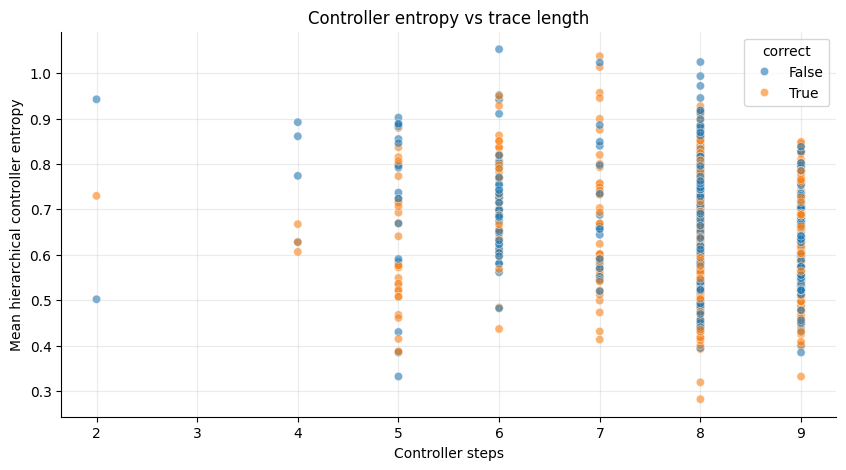

,domain,samples,accuracy,mean_controller_entropy,mean_action_entropy,mean_steps
2,science,779,58.92%,0.6696,0.6696,8.00
0,commonsense,217,71.89%,0.6149,0.6149,7.63
1,mathematics,112,51.79%,0.6504,0.6504,8.06


Confident errors: incorrect samples with the lowest controller entropy


,example_id,domain,topic,gold_answer,generated_text,controller_entropy_mean,controller_action_entropy_mean,num_controller_steps
56,social-commonsense-1734,commonsense,social-commonsense,a,"Therefore, the answer is D",0.331813,0.331813,5
386,writing-strategies-317,science,language-science,b,"Therefore, the answer is A",0.384593,0.384593,9
132,social-commonsense-1531,commonsense,social-commonsense,b,"Therefore, the answer is A",0.384788,0.384788,5
160,temporal-commonsense-135,commonsense,temporal-commonsense,d,"Therefore, the answer is C",0.394385,0.394385,8
371,reading-comprehension-26,science,language-science,a,"Therefore, the answer is B",0.398637,0.398637,9
1,physical-commonsense-1409,commonsense,physical-commonsense,d,"Therefore, the answer is C",0.429939,0.429939,5
513,biology-16,science,natural-science,c,"Therefore, the answer is E",0.431613,0.431613,8
537,biology-995,science,natural-science,b,"Therefore, the answer is A",0.432339,0.432339,9
1073,geography-3495,science,social-science,c,"Therefore, the answer is A",0.440574,0.440574,8
684,physical-commonsense-1150,science,natural-science,c,"Therefore, the answer is B",0.440714,0.440714,8


Uncertain successes: correct samples with the highest controller entropy


,example_id,domain,topic,gold_answer,generated_text,controller_entropy_mean,controller_action_entropy_mean,num_controller_steps
868,economics-42,science,social-science,b,"Therefore, the answer is B",1.037477,1.037477,7
952,economics-888,science,social-science,a,"Therefore, the answer is A",1.013629,1.013629,7
181,mathematics-1519,commonsense,temporal-commonsense,a,"Therefore, the answer is A",0.956991,0.956991,7
944,economics-775,science,social-science,a,"Therefore, the answer is A",0.949909,0.949909,6
704,physical-commonsense-1120,science,natural-science,c,"Therefore, the answer is C",0.945338,0.945338,7
903,economics-532,science,social-science,d,"Therefore, the answer is D",0.928247,0.928247,6
599,physics-1554,science,natural-science,b,"Therefore, the answer is B",0.927511,0.927511,8
295,mathematics-765,mathematics,geometry,b,"Therefore, the answer is B",0.917850,0.917850,8
278,mathematics-1373,mathematics,algebra,b,"Therefore, the answer is B",0.912774,0.912774,8
729,physical-commonsense-653,science,natural-science,c,"Therefore, the answer is C",0.907809,0.907809,8


In [39]:
controller_metadata = (
    predictions[predictions["run_type"] == "full_lvar"]
    .drop_duplicates("example_id")
    [["example_id", "domain", "topic", "generated_text", "gold_answer", "num_inference_trace_actions", "num_output_tokens"]]
)
controller_samples = controller_entropy_run.merge(controller_metadata, on="example_id", how="left", suffixes=("", "_prediction"))
controller_samples["num_controller_steps"] = controller_samples["controller_entropies"].map(lambda x: len(x) if isinstance(x, list) else np.nan)

if not controller_samples.empty:
    relationship_cols = ["controller_entropy_mean", "controller_action_entropy_mean", "controller_region_entropy_mean", "controller_patch_entropy_mean", "num_controller_steps", "num_output_tokens"]
    controller_correlations = controller_samples[relationship_cols].corr(method="spearman")
    display(controller_correlations.style.format("{:.3f}").set_caption("Spearman correlations among entropy and sequence lengths"))

    if HAS_SEABORN:
        sns.scatterplot(data=controller_samples, x="num_controller_steps", y="controller_entropy_mean", hue="correct", alpha=0.6)
    else:
        for correct, group in controller_samples.groupby("correct"):
            plt.scatter(group["num_controller_steps"], group["controller_entropy_mean"], alpha=0.6, label=f"correct={correct}")
        plt.legend()
    plt.xlabel("Controller steps")
    plt.ylabel("Mean hierarchical controller entropy")
    plt.title("Controller entropy vs trace length")
    plt.show()

    controller_domain_summary = (
        controller_samples.groupby("domain", dropna=False)
        .agg(
            samples=("example_id", "size"),
            accuracy=("correct", "mean"),
            mean_controller_entropy=("controller_entropy_mean", "mean"),
            mean_action_entropy=("controller_action_entropy_mean", "mean"),
            mean_steps=("num_controller_steps", "mean"),
        )
        .reset_index()
        .sort_values("samples", ascending=False)
    )
    display(controller_domain_summary.style.format({"accuracy": "{:.2%}", "mean_controller_entropy": "{:.4f}", "mean_action_entropy": "{:.4f}", "mean_steps": "{:.2f}"}))

    diagnostic_cols = ["example_id", "domain", "topic", "gold_answer", "generated_text", "controller_entropy_mean", "controller_action_entropy_mean", "num_controller_steps"]
    print("Confident errors: incorrect samples with the lowest controller entropy")
    display(controller_samples[~controller_samples["correct"]].nsmallest(12, "controller_entropy_mean")[diagnostic_cols])
    print("Uncertain successes: correct samples with the highest controller entropy")
    display(controller_samples[controller_samples["correct"]].nlargest(12, "controller_entropy_mean")[diagnostic_cols])


## 5. Error And Success Examples For Inspection

These tables surface examples where trace mining strongly reduced CE but inference was still wrong, and examples that were correct despite weak or low CE reduction. They are useful candidates for qualitative trace inspection.

In [40]:
def compact_question(text):
    if not isinstance(text, str):
        return text
    text = re.sub(r"\s+", " ", text).strip()
    return text[:260] + ("..." if len(text) > 260 else "")

inspection_cols = [
    "example_id", "topic", "gold_answer", "generated_text", "raw_answer", "total_ce_reduction",
    "num_trace_actions", "num_patches", "num_regions", "num_noop_decisions", "question"
]

if selected_run.empty:
    print("No rows for the selected run. Adjust SELECT_* variables above.")
else:
    display_run = selected_run.copy()
    display_run["question"] = display_run["question"].map(compact_question)

    print("Wrong despite high mined CE reduction")
    display(display_run[~display_run["correct"]].sort_values("total_ce_reduction", ascending=False)[inspection_cols].head(15))

    print("Correct despite low mined CE reduction")
    display(display_run[display_run["correct"]].sort_values("total_ce_reduction", ascending=True)[inspection_cols].head(15))

No rows for the selected run. Adjust SELECT_* variables above.


## 6. Domain And Topic Breakdown

This checks whether trace benefit and final correctness vary across M3CoT domains/topics. It can help identify whether a trace setting is helping visual grounding broadly or only for a subset.

In [41]:
domain_summary = (
    correctness_traces
    .groupby(["mined_by", "context", "replay_context", "evaluated_by", "trace_variant_label", "domain"])
    .agg(
        examples=("example_id", "nunique"),
        accuracy=("correct", "mean"),
        mean_total_ce_reduction=("total_ce_reduction", "mean"),
        mean_trace_actions=("num_trace_actions", "mean"),
    )
    .reset_index()
)
domain_summary["accuracy_pct"] = 100 * domain_summary["accuracy"]
domain_summary.sort_values(["trace_variant_label", "accuracy"], ascending=[True, False]).head(40).style.format({
    "accuracy": "{:.4f}",
    "accuracy_pct": "{:.2f}",
    "mean_total_ce_reduction": "{:.4f}",
    "mean_trace_actions": "{:.2f}",
})

,mined_by,context,replay_context,evaluated_by,trace_variant_label,domain,examples,accuracy,mean_total_ce_reduction,mean_trace_actions,accuracy_pct
0,full_lvar,global,global,lvar+controller,controller-generated,commonsense,217,0.7189,nan,nan,71.89
2,full_lvar,global,global,lvar+controller,controller-generated,science,779,0.5892,nan,nan,58.92
1,full_lvar,global,global,lvar+controller,controller-generated,mathematics,112,0.5179,nan,nan,51.79
21,lvar,coarse,global,ivtlr,filtered (cap),commonsense,217,0.7604,0.7055,8.64,76.04
48,lvar,global,global,lvar,filtered (cap),commonsense,217,0.7512,0.5411,6.72,75.12
39,lvar,global,global,ivtlr,filtered (cap),commonsense,217,0.7465,0.5411,6.72,74.65
30,lvar,coarse,global,lvar,filtered (cap),commonsense,217,0.7189,0.7055,8.64,71.89
50,lvar,global,global,lvar,filtered (cap),science,779,0.6329,0.4550,8.41,63.29
41,lvar,global,global,ivtlr,filtered (cap),science,779,0.6316,0.4550,8.41,63.16
23,lvar,coarse,global,ivtlr,filtered (cap),science,779,0.6290,0.7470,11.84,62.90


In [42]:
if not selected_run.empty and "domain" in selected_run:
    domain_selected = (
        selected_run
        .groupby(["domain", "correct"])
        .agg(examples=("example_id", "nunique"), mean_total_ce_reduction=("total_ce_reduction", "mean"))
        .reset_index()
    )
    if HAS_SEABORN:
        sns.barplot(data=domain_selected, x="domain", y="mean_total_ce_reduction", hue="correct")
        plt.xticks(rotation=30, ha="right")
        plt.title("Selected run: CE reduction by domain and correctness")
        plt.tight_layout()
        plt.show()
    else:
        domain_selected.pivot_table(index="domain", columns="correct", values="mean_total_ce_reduction").plot(kind="bar", figsize=(10, 5))
        plt.ylabel("Mean total CE reduction")
        plt.tight_layout()
        plt.show()

## 7. Export Analysis Tables

Optional: write the core dataframes as CSVs for reporting or deeper offline analysis.

In [43]:
EXPORT_TABLES = False
EXPORT_DIR = ROOT / "analysis/validation_trace_answer_analysis_tables"

if EXPORT_TABLES:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    accuracy_df.to_csv(EXPORT_DIR / "accuracy_by_setting.csv", index=False)
    trace_manifest.to_csv(EXPORT_DIR / "trace_manifest.csv", index=False)
    trace_overview.to_csv(EXPORT_DIR / "trace_overview.csv", index=False)
    ce_summary.to_csv(EXPORT_DIR / "ce_summary.csv", index=False)
    correctness_summary.to_csv(EXPORT_DIR / "correctness_trace_summary.csv", index=False)
    domain_summary.to_csv(EXPORT_DIR / "domain_summary.csv", index=False)
    entropy_df.drop(columns=["answer_option_probabilities", "decoded_token_entropies"], errors="ignore").to_csv(EXPORT_DIR / "entropy_by_sample.csv", index=False)
    entropy_summary.to_csv(EXPORT_DIR / "entropy_summary.csv", index=False)
    entropy_discrimination.to_csv(EXPORT_DIR / "entropy_discrimination.csv", index=False)
    print(f"Wrote tables to {EXPORT_DIR}")
else:
    print("Set EXPORT_TABLES = True to write CSV outputs.")

Set EXPORT_TABLES = True to write CSV outputs.
